# Meteo: Air temperature (TA) (2005-2025)

**Author**: Lukas Hörtnagl (holukas@ethz.ch)

# About this notebook

Overview of the gap-filled air temperature product of CH-LAE. The product is produced by
`10_METEO/30_PRODUCTS/02_METEO_TA_2004-2025.ipynb`; this notebook computes and corrects nothing,
it only describes what was exported.

**The 47 m record spans two instruments.** On 21 January 2016 the sensor and its acquisition system
were replaced together — a Rotronic MP101A read as a single-ended analog voltage gave way to a
Campbell CS215 on SDI-12 — and the earlier chain carried a constant zero-point error of about
-11 mV, so the pre-2016 record reads about 1.3 °C too cold. The product therefore exports the
series twice.

**Columns of the product**

- `TA_T1_47_1_gfXG` — air temperature (°C), continuous, gap-filled, as the instrument reported.
  Not homogeneous across 21 January 2016
- `TA_T1_47_1_HOMOGENIZED_gfXG` — the same series with the pre-2016 era raised onto the level of
  the later era
- `FLAG_TA_T1_47_1_ISFILLED` — `0` = measured, `1` = XGBoost model, `2` = timestamp-only fallback
  model, `4` = linear interpolation of a short gap, `5` = reconstructed from NABEL at 49 m on the
  same tower. There is no code `3`
- `FLAG_TA_T1_47_1_SOURCE` — `0` = Campbell CS215 era, `1` = Rotronic MP101A era, `2` = the
  January 2016 changeover, sensor era undetermined, `3` = before the tower record begins in
  September 2004

**Which column this notebook uses.** Almost everything below compares years with one another, and
a comparison that crosses January 2016 on the measured column reports the instrument rather than
the climate: the difference between the 2005-2015 and 2016-2025 period means is about +2.3 °C on
the measured column against about +1.1 °C on the homogenised one. **The homogenised column is
therefore used throughout**, and the measured column appears only where the point is to report what
the instrument recorded. Every table and figure states which of the two it used.

::: {.callout-warning title="The homogenisation corrects the level, not the shape"}

The two sensors had different radiation shields, so the correction cannot make the eras identical
in anything that depends on the shape of the daily cycle. Daily minima and monthly means are
homogeneous to roughly 0.2 °C, but **daily maxima and diurnal ranges carry a residual step of
about +0.7 to +0.8 °C at the break**. Everything built on daily maxima — summer days, hot days,
tropical nights, warm-spell lengths, new record highs — is therefore *not* comparable across 2016
even in the homogenised column, and is marked where it appears.

:::

**Timestamps.** The product is stored on `TIMESTAMP_MIDDLE` at 30 minutes, so a record labelled
`16:45` is the average over `16:30` to `17:00`. Wherever a single record is quoted below, its
averaging window is reported instead of its timestamp.

**Two conventions used throughout**

- *Extremes are taken from measured records only.* A gap-filled value is a model result and cannot
  set a record. Means, counts and indices use the full series, which is why the gap-filled share of
  each year is reported before any statistic.
- *Yearly means are means of yearly means.* The overall mean averages the yearly means, so every
  year carries the same weight. The mean over all records is printed next to it for comparison.


</br>

# Settings

In [1]:
# Identity of the series in the product file.
#
# The product carries the series twice: as the instrument reported it, and with the pre-2016 era
# raised onto the level of the post-2016 era. Nearly every statistic in this notebook compares
# years across the 21 January 2016 sensor change, so the homogenised column is the default and the
# measured one is kept beside it for the sections that report what was actually recorded.
varname = 'TA_T1_47_1_HOMOGENIZED_gfXG'  # used for everything unless stated otherwise
varname_measured = 'TA_T1_47_1_gfXG'  # what the instrument reported, not homogeneous across 2016
flagname = 'FLAG_TA_T1_47_1_ISFILLED'
sourcename = 'FLAG_TA_T1_47_1_SOURCE'
var = "TA"  # Name shown in plots
units = "°C"

# What the fill flag codes mean, taken from the notebook that produced the product
# (10_METEO/30_PRODUCTS/02). Used in the coverage section. There is no code 3: that is the
# nighttime-zero branch of the SW_IN gap-filler and does not apply to temperature.
FLAG_LEGEND = {
    0: 'measured',
    1: 'XGBoost model',
    2: 'timestamp-only fallback model',
    4: 'linear interpolation (short gap)',
    5: 'reconstructed from NABEL at 49 m',
}

# Which instrument a record belongs to. Codes 2 and 3 mark records that no sensor produced.
FLAG_SOURCE_LEGEND = {
    0: 'Campbell CS215, SDI-12 (from 21 Jan 2016)',
    1: 'Rotronic MP101A, analog (to 31 Dec 2015)',
    2: 'acquisition changeover, era undetermined',
    3: 'before the tower record begins',
}

# Period covered by this overview. The product itself starts in 2004, but 2004 is incomplete: the
# tower record begins on 20 September 2004, so 72 % of that year is modelled and its level is set
# by the reconstruction rather than measured.
FIRST_YEAR = 2005
LAST_YEAR = 2025

# Analysis parameters.
N_RECENT_YEARS = 10  # length of the recent period in the period means
N_RANKED = 5  # number of years listed as warmest and coolest
N_EXTREMES = 10  # number of records listed in the extremes tables
REFERENCE_START_YEAR = FIRST_YEAR  # reference period for all anomalies
REFERENCE_END_YEAR = LAST_YEAR

# Physical limits for the integrity check. Wide on purpose: they catch a broken unit or a failed
# gap-filling, not an unusual day.
LIMITS = (-40.0, 45.0)

# The appendix draws two figures per year. Switch it off for a quick run.
SHOW_PER_YEAR_DETAIL = True


# Imports

In [2]:
import calendar
import importlib.metadata
import textwrap
import warnings
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import Normalize
from scipy.stats import kendalltau, theilslopes

import diive as dv
from diive.core.io.files import save_parquet, load_parquet
from diive.core.plotting.cumulative import CumulativeYear
from diive.core.plotting.bar import LongtermAnomaliesYear

warnings.filterwarnings(action='ignore', category=FutureWarning)
warnings.filterwarnings(action='ignore', category=UserWarning)
version_diive = importlib.metadata.version("diive")
print(f"diive version: v{version_diive}")

diive version: v0.91.0


# Helpers

In [3]:
def per_year(s, how='mean'):
    """Aggregate `s` to one value per year, indexed by the year number instead of by a timestamp."""
    out = s.resample('YE').agg(how)
    out.index = out.index.year
    out.index.name = 'YEAR'
    return out


def per_year_month(s, how='mean', month_names=True):
    """Aggregate `s` to a table of YEAR (rows) by MONTH (columns)."""
    out = s.groupby([s.index.year, s.index.month]).agg(how).unstack()
    out.index.name = 'YEAR'
    if month_names:
        out.columns = [calendar.month_abbr[m] for m in out.columns]
    return out


def tabcap(text, width=100):
    """Print a table caption. Called by `styled`, so no table can be shown without one."""
    print(textwrap.fill(f"Table — {text}", width) + "\n")


def figcap(fig, text, width=125):
    """Place a caption under a figure. Call after the last axes of that figure is drawn.

    A figure drawn with a layout engine makes room for a caption by itself. The figures pandas and
    diive build have no engine, and a caption placed in them lands on top of the tick labels. For
    those the figure is extended downwards by the height of the caption and every axes is moved up
    by the same amount, so the drawing keeps its size and position and the caption gets a free
    strip below it. `width` is the widest the caption may wrap, narrowed for a narrow figure.
    """
    # A fixed wrap width runs off the side of a narrow figure, so it is capped by how many
    # characters of this font size fit across the figure.
    width = min(width, max(40, int(14.5 * fig.get_size_inches()[0])))
    caption = textwrap.fill(f"Figure — {text}", width)
    if fig.get_layout_engine() is not None:
        fig.supxlabel(caption, fontsize=9, ha='left', x=0.005)
        return
    lines = len(caption.splitlines())
    extra = 0.17 * lines + 0.12  # inches, one caption line is about 0.17 in at fontsize 9
    width_in, height_in = fig.get_size_inches()
    fig.set_size_inches(width_in, height_in + extra)
    keep = height_in / (height_in + extra)  # the old figure as a fraction of the new one
    offset = extra / (height_in + extra)
    for ax in fig.axes:
        pos = ax.get_position()
        ax.set_position([pos.x0, offset + pos.y0 * keep, pos.width, pos.height * keep])
    fig.text(0.005, 0.01, caption, fontsize=9, ha='left', va='bottom')


def window(tsmid):
    """The averaging window of a 30MIN record stored on TIMESTAMP_MIDDLE, as text."""
    start = tsmid - pd.Timedelta('15min')
    end = tsmid + pd.Timedelta('15min')
    return f"{start:%d %b %Y}, {start:%H:%M} to {end:%H:%M}"


def styled(data, caption, fmt="{:.1f}", subset=None, cmap="RdYlBu_r", axis=0, center=False):
    """`data` as a table with a caption, fixed decimals and a colour scale over its values.

    The caption is printed above the table, so it is written as a sentence about what the table
    shows rather than as a title. `center` puts the midpoint of the colour scale at zero, and
    `axis=None` scales the colours across the whole table instead of column by column. The colour
    scale sets a text colour per cell, so the numbers stay readable in both the light and the dark
    version of the rendered page.
    """
    # Formats apply to numbers only, so text columns are dropped from the map. Without this a
    # table carrying a date or a label raises at render time, not at call time.
    numeric = [c for c in data.columns if pd.api.types.is_numeric_dtype(data[c])]
    fmt = {c: fmt for c in numeric} if isinstance(fmt, str) else {
        c: f for c, f in fmt.items() if c in numeric}
    tabcap(caption)
    styler = data.style.format(fmt, na_rep="-")
    if cmap is None:
        return styler
    limits = {}
    if center:
        values = data[subset] if subset is not None else data
        absmax = np.nanmax(np.abs(values.to_numpy(dtype=float)))
        limits = dict(vmin=-absmax, vmax=absmax)
    return styler.background_gradient(cmap=cmap, subset=subset, axis=axis,
                                      text_color_threshold=0.4, **limits)


def anomaly_bars(styler, column):
    """Draw in-cell bars for an anomaly column, in the colours of the anomaly plots."""
    return styler.bar(subset=[column], align='zero', color=['#42A5F5', '#EF5350'])


def trend(yearly):
    """Theil-Sen slope per decade of a yearly series, with its 95 % interval and Kendall's tau.

    Theil-Sen rather than least squares because a single extreme year does not move it, and
    Kendall's tau because it tests a monotonic trend without assuming normal residuals.
    """
    years = yearly.index.to_numpy(dtype=float)
    values = yearly.to_numpy(dtype=float)
    slope, intercept, low, high = theilslopes(values, years, alpha=0.95)
    tau, pvalue = kendalltau(years, values)
    return dict(slope=slope * 10, low=low * 10, high=high * 10, tau=tau, pvalue=pvalue,
                fit=pd.Series(intercept + slope * years, index=yearly.index))


def longest_spell(mask):
    """Length in days and start date of the longest run of True in a daily boolean series."""
    blocks = mask.ne(mask.shift()).cumsum()
    runs = mask[mask].groupby(blocks[mask]).size()
    if runs.empty:
        return 0, pd.NaT
    return int(runs.max()), mask.index[blocks == runs.idxmax()][0]


def growing_season(daily_mean, base=5.0, span=6):
    """Start, end and length of the growing season of one year.

    Definition used here: the season starts on the first day of the first `span` consecutive days
    with a daily mean above `base`, and ends on the first day of the first such span below `base`
    after 1 July. Several conventions are in use, so the numbers only mean something together with
    this definition.
    """
    above = daily_mean > base
    runs = above.rolling(span).sum()
    starts = runs[runs == span]
    if starts.empty:
        return None
    start = starts.index[0] - pd.Timedelta(days=span - 1)
    second_half = (~above).loc[f"{daily_mean.index[0].year}-07-01":]
    runs_below = second_half.rolling(span).sum()
    ends = runs_below[runs_below == span]
    end = ends.index[0] - pd.Timedelta(days=span - 1) if not ends.empty else daily_mean.index[-1]
    return dict(start=start, end=end, length=(end - start).days)

</br>

# Load data

In [4]:
# Gap-filled TA produced by notebook 10_METEO/30_PRODUCTS/02. Data files live in the external
# (untracked) data folder, mirroring the workflow tree of this repo.
SOURCEDIR = r"F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data\workflow\10_METEO\30_PRODUCTS"
FILENAME = r"02_METEO_TA_GAPFILLED_2004-2025.parquet"
FILEPATH = Path(SOURCEDIR) / FILENAME
df = load_parquet(filepath=FILEPATH)

# The source product starts in 2004, this overview covers FIRST_YEAR to LAST_YEAR.
keeplocs = (df.index.year >= FIRST_YEAR) & (df.index.year <= LAST_YEAR)
df = df[keeplocs].copy()

print(f"Columns: {list(df.columns)}")
print(f"Range:   {df.index[0]} -> {df.index[-1]} ({len(df):,} records)")
df

> Loaded .parquet file 
F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data\workflow\10_METEO\30_PRODU
CTS\02_METEO_TA_GAPFILLED_2004-2025.parquet (0.047 seconds).

Columns: ['TA_T1_47_1_gfXG', 'FLAG_TA_T1_47_1_ISFILLED', 'TA_T1_47_1_HOMOGENIZED_gfXG', 'FLAG_TA_T1_47_1_SOURCE']
Range:   2005-01-01 00:15:00 -> 2025-12-31 23:45:00 (368,160 records)


,TA_T1_47_1_gfXG,FLAG_TA_T1_47_1_ISFILLED,TA_T1_47_1_HOMOGENIZED_gfXG,FLAG_TA_T1_47_1_SOURCE
TIMESTAMP_MIDDLE,,,,
2005-01-01 00:15:00,-2.160000,0,-0.840326,1
2005-01-01 00:45:00,-2.010000,0,-0.690326,1
2005-01-01 01:15:00,-1.791000,0,-0.471326,1
2005-01-01 01:45:00,-1.539000,0,-0.219326,1
2005-01-01 02:15:00,-1.338000,0,-0.018326,1
...,...,...,...,...
2025-12-31 21:45:00,-3.081644,0,-3.081644,0
2025-12-31 22:15:00,-3.084372,0,-3.084372,0
2025-12-31 22:45:00,-3.423939,0,-3.423939,0


In [5]:
series = df[varname].copy()
series

TIMESTAMP_MIDDLE
2005-01-01 00:15:00   -0.840326
2005-01-01 00:45:00   -0.690326
2005-01-01 01:15:00   -0.471326
2005-01-01 01:45:00   -0.219326
2005-01-01 02:15:00   -0.018326
                         ...   
2025-12-31 21:45:00   -3.081644
2025-12-31 22:15:00   -3.084372
2025-12-31 22:45:00   -3.423939
2025-12-31 23:15:00   -3.437078
2025-12-31 23:45:00   -3.546789
Freq: 30min, Name: TA_T1_47_1_HOMOGENIZED_gfXG, Length: 368160, dtype: float64

In [6]:
xlabel = f"{var} ({units})"
xlim = [series.min(), series.max()]

## Integrity checks

In [7]:
# The overview describes the product, so it starts by checking that the product is what everything
# below assumes: one continuous 30MIN record, no duplicates, no gaps left in either value column,
# nothing outside the physical limits, and complete years. A silent violation here would be
# reported as a result.
_expected = pd.date_range(start=df.index[0], end=df.index[-1], freq='30min')
assert df.index.equals(_expected), "index is not continuous at 30MIN"
assert not df.index.duplicated().any(), "duplicate timestamps"
for _col in (varname, varname_measured):
    assert df[_col].notna().all(), f"{_col} is gap-filled and must not contain missing values"
    assert df[_col].between(*LIMITS).all(), (
        f"{_col} outside {LIMITS}: {df[_col].min()} to {df[_col].max()}")
assert df[flagname].isin(FLAG_LEGEND).all(), (
    f"unknown fill flag codes: {sorted(set(df[flagname].unique()) - set(FLAG_LEGEND))}")
assert df[sourcename].isin(FLAG_SOURCE_LEGEND).all(), (
    f"unknown source flag codes: {sorted(set(df[sourcename].unique()) - set(FLAG_SOURCE_LEGEND))}")

_records = df[varname].resample('YE').count()
_expected_records = [17568 if calendar.isleap(y) else 17520 for y in _records.index.year]
assert (_records.to_numpy() == _expected_records).all(), f"incomplete years:\n{_records}"

# The two value columns must differ by a single constant before the sensor change and not at all
# after it. That is the whole content of the homogenisation, and checking it here means the rest of
# this notebook can quote either column without re-establishing what separates them.
_delta = (df[varname] - df[varname_measured]).round(6)
_pre = _delta[df[sourcename] != 0]
_post = _delta[df[sourcename] == 0]
assert _pre.nunique() == 1, f"the pre-2016 offset is not a single constant: {sorted(_pre.unique())}"
assert (_post == 0).all(), "the post-2016 era was modified by the homogenisation"
OFFSET = float(_pre.iloc[0])

print(f"Integrity checks passed for {FIRST_YEAR}-{LAST_YEAR}.")
print(f"Homogenisation offset applied before the sensor change: {OFFSET:+.4f} {units}")
print(f"Sensor change at: {df.index[df[sourcename] == 0][0]}")


Integrity checks passed for 2005-2025.
Homogenisation offset applied before the sensor change: +1.3197 °C
Sensor change at: 2016-01-21 14:15:00


## Derived series

In [8]:
# Two series that several sections need, derived once here.
#
# `series_measured` holds the measured records only and is what the extremes are read from; it has
# gaps by construction. `daily` carries the daily minimum, mean and maximum used by the threshold
# days, the growing season and the annual cycle, plus the gap-filled share of each day, so a daily
# value that mostly comes from the model can be recognised as such.
series_measured = series.where(df[flagname] == 0).rename(f"{varname}_MEASURED")

daily = series.resample('D').agg(['min', 'mean', 'max'])
daily['gap-filled (%)'] = df[flagname].gt(0).resample('D').mean() * 100

# Daily extremes of the measured records only, for the sections that report records. Reading them
# from the measured series can miss a record that fell into a gap, but it can never invent one.
daily_measured = series_measured.resample('D').agg(['min', 'max'])

print(f"Measured records: {series_measured.notna().sum():,} of {len(series):,} "
      f"({series_measured.notna().mean() * 100:.1f} %)")
daily

Measured records: 364,143 of 368,160 (98.9 %)


,min,mean,max,gap-filled (%)
TIMESTAMP_MIDDLE,,,,
2005-01-01,-0.840326,1.918299,4.419674,0.0
2005-01-02,0.363674,2.656737,4.294674,0.0
2005-01-03,-0.588326,0.624737,2.600674,0.0
2005-01-04,-1.501326,1.004695,4.149674,0.0
2005-01-05,-0.554326,2.249654,4.311675,0.0
...,...,...,...,...
2025-12-27,-3.613494,-3.315856,-3.089517,0.0
2025-12-28,-3.676228,-3.066524,-1.577122,0.0
2025-12-29,-5.107550,-3.852470,-3.345239,0.0


</br>

# Coverage and provenance

How much of the product is measured and where the filled records sit. This comes before the statistics because it says how far each year can be read as a measurement.

In [9]:
# How much of each year was measured, and by which method the rest was filled. Every statistic
# below is computed on the full series, so this table says how far each year can be read as a
# measurement. The longest uninterrupted run of filled records is listed separately: a year filled
# in many short gaps is not the same as a year with one long outage.
_isfilled = df[flagname] > 0

coverage = pd.DataFrame({"records": per_year(series, 'count')})
for _flagcode, _label in FLAG_LEGEND.items():
    if _flagcode == 0:
        continue
    coverage[_label] = per_year(df[flagname].eq(_flagcode).astype(float), 'sum')
coverage["gap-filled (%)"] = per_year(_isfilled.astype(float), 'mean') * 100

_blocks = _isfilled.ne(_isfilled.shift()).cumsum()[_isfilled]
_lengths = _isfilled[_isfilled].groupby(_blocks).size() * 0.5  # 30MIN records -> hours
_years = df.index[_isfilled].to_series().groupby(_blocks.to_numpy()).first().dt.year
coverage["longest gap (h)"] = (pd.Series(_lengths.to_numpy(), index=_years.to_numpy())
                               .groupby(level=0).max())
coverage = coverage.fillna(0)

_fmt = {c: "{:.0f}" for c in coverage.columns}
_fmt.update({"gap-filled (%)": "{:.1f}", "longest gap (h)": "{:.1f}"})
display(styled(coverage, caption=f"coverage of the {var} product per year: how many records were measured, how many "
                       f"were filled by each method, and the longest uninterrupted filled run. The "
                       f"years holding a multi-week outage stand apart from the rest, which are "
                       f"filled in short gaps only", fmt=_fmt,
               subset=["gap-filled (%)", "longest gap (h)"], cmap="Reds"))

Table — coverage of the TA product per year: how many records were measured, how many were filled by
each method, and the longest uninterrupted filled run. The years holding a multi-week outage stand
apart from the rest, which are filled in short gaps only



,records,XGBoost model,timestamp-only fallback model,linear interpolation (short gap),reconstructed from NABEL at 49 m,gap-filled (%),longest gap (h)
YEAR,,,,,,,
2005,17520,0,24,10,0,0.2,12.0
2006,17520,14,0,12,0,0.1,7.0
2007,17520,0,0,13,0,0.1,1.0
2008,17568,4,0,16,0,0.1,2.0
2009,17520,468,0,16,0,2.8,234.0
2010,17520,157,0,12,0,1.0,78.5
2011,17520,1,9,11,0,0.1,5.0
2012,17568,1207,0,14,41,7.2,312.0
2013,17520,53,0,33,0,0.5,26.5


## Which instrument each year came from

The fill flag says whether a record was measured; this says which sensor measured it. Codes `2`
and `3` are records that no instrument stands behind — the January 2016 changeover, and the months
before the tower record begins — and they are the rows to drop if provenance has to be certain.


In [10]:
# Share of each year by instrument era. A year split between two codes is a year that cannot be
# compared with an undivided one without the homogenisation.
_src = pd.crosstab(df.index.year, df[sourcename])
_src.columns = [FLAG_SOURCE_LEGEND[c] for c in _src.columns]
_src.index.name = 'YEAR'
_src_pct = (_src.div(_src.sum(axis=1), axis=0) * 100)

display(styled(_src_pct, caption=f"share of each year (%) by instrument era. The sensor changed on "
                                 f"21 January 2016, which is why {df.index[df[sourcename] == 0][0]:%Y} "
                                 f"is the one year drawing on both. Codes marking records no "
                                 f"instrument produced are listed beside them",
               fmt="{:.1f}", cmap="Blues"))

# Codes 2 and 3 mark records no sensor produced. Code 3 lies entirely in 2004, which this
# overview excludes, so only the January 2016 changeover survives the FIRST_YEAR cut.
_n_no_sensor = int(df[sourcename].isin([2, 3]).sum())
print(f"Records no instrument stands behind: {_n_no_sensor:,} "
      f"({100 * _n_no_sensor / len(df):.2f} % of {FIRST_YEAR}-{LAST_YEAR}).")
print(f"Source codes present in {FIRST_YEAR}-{LAST_YEAR}: {sorted(df[sourcename].unique())}. "
      f"Code 3 (before the tower record begins) falls entirely in 2004 and is outside this "
      f"overview.")


Table — share of each year (%) by instrument era. The sensor changed on 21 January 2016, which is
why 2016 is the one year drawing on both. Codes marking records no instrument produced are listed
beside them



,"Campbell CS215, SDI-12 (from 21 Jan 2016)","Rotronic MP101A, analog (to 31 Dec 2015)","acquisition changeover, era undetermined"
YEAR,,,
2005,0.0,100.0,0.0
2006,0.0,100.0,0.0
2007,0.0,100.0,0.0
2008,0.0,100.0,0.0
2009,0.0,100.0,0.0
2010,0.0,100.0,0.0
2011,0.0,100.0,0.0
2012,0.0,100.0,0.0
2013,0.0,100.0,0.0


Records no instrument stands behind: 988 (0.27 % of 2005-2025).
Source codes present in 2005-2025: [np.int64(0), np.int64(1), np.int64(2)]. Code 3 (before the tower record begins) falls entirely in 2004 and is outside this overview.


## Gap-filled share per year and month

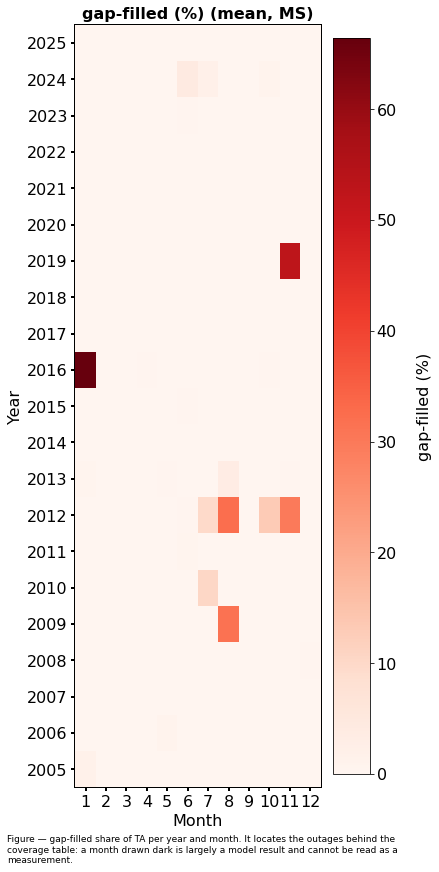

In [11]:
# Where the filled records sit. A month that is largely filled cannot be read as a measurement:
# a mean over it says as much about the gap-filling model as about the site.
fig, ax = plt.subplots(figsize=(6, 12), dpi=72, layout="constrained")
_filled_pct = (df[flagname].gt(0).astype(float) * 100).rename("gap-filled (%)")
dv.plotting.HeatmapYearMonth(series=_filled_pct, agg='mean').plot(
    ax=ax, cmap="Reds", cb_digits_after_comma=0, zlabel="gap-filled (%)")
figcap(fig, f"gap-filled share of {var} per year and month. It locates the outages behind the "
            f"coverage table: a month drawn dark is largely a model result and cannot be read as a "
            f"measurement.")

</br>

# Summary statistics

## Overall mean

In [12]:
# Mean of the yearly means, with the standard deviation between years. The mean over all records
# is printed next to it: the two differ slightly because years have different lengths.
_yearly_avg = series.resample('YE').mean()
_overall_mean = _yearly_avg.mean()
_overall_sd = _yearly_avg.std()
print(f"Overall mean (mean of yearly means): {_overall_mean:.2f} {units} "
      f"+/- {_overall_sd:.2f} {units} SD between years")
print(f"Mean over all records:               {series.mean():.2f} {units}")
print(f"Computed from {varname} (homogenised).")

Overall mean (mean of yearly means): 9.70 °C +/- 0.80 °C SD between years
Mean over all records:               9.70 °C
Computed from TA_T1_47_1_HOMOGENIZED_gfXG (homogenised).


## Yearly means

In [13]:
# One table for the year-by-year view: the mean and its anomaly against the record, the extremes
# the year reached, its rank, the two threshold-day counts detailed further below, and how much of
# it was gap-filled.
ym = per_year(series, 'mean')

yearly = pd.DataFrame({
    f"mean ({units})": ym,
    f"measured minimum ({units})": per_year(series_measured, 'min'),
    f"measured maximum ({units})": per_year(series_measured, 'max'),
    f"anomaly ({units})": ym - ym.mean(),
    "rank (warmest first)": ym.rank(ascending=False).astype(int),
    "frost days": per_year(daily['min'].lt(0).astype(float), 'sum'),
    "hot days": per_year(daily['max'].ge(30).astype(float), 'sum'),
    "gap-filled (%)": per_year(df[flagname].gt(0).astype(float), 'mean') * 100,
})

_fmt = {c: "{:.1f}" for c in yearly.columns}
_fmt.update({"rank (warmest first)": "{:.0f}", "frost days": "{:.0f}", "hot days": "{:.0f}"})
_styler = styled(yearly, caption=f"{var} per year: the mean and its anomaly against the record, the measured "
                         f"extremes of the year, its rank, the two threshold-day counts detailed "
                         f"further below, and the gap-filled share that says how far the row is a "
                         f"measurement", fmt=_fmt,
                 subset=[f"mean ({units})", f"measured minimum ({units})",
                         f"measured maximum ({units})"])
display(anomaly_bars(_styler, f"anomaly ({units})"))

Table — TA per year: the mean and its anomaly against the record, the measured extremes of the year,
its rank, the two threshold-day counts detailed further below, and the gap-filled share that says
how far the row is a measurement



,mean (°C),measured minimum (°C),measured maximum (°C),anomaly (°C),rank (warmest first),frost days,hot days,gap-filled (%)
YEAR,,,,,,,,
2005,8.7,-13.1,32.1,-1.0,19,105,5,0.2
2006,9.3,-10.4,31.6,-0.4,14,88,6,0.1
2007,9.4,-8.4,31.2,-0.3,13,58,2,0.1
2008,8.9,-6.4,28.5,-0.8,18,79,0,0.1
2009,9.3,-15.1,31.0,-0.4,15,83,3,2.8
2010,8.1,-9.8,32.3,-1.6,21,96,4,1.0
2011,10.1,-8.4,32.0,0.4,8,53,4,0.1
2012,9.1,-15.9,31.6,-0.6,16,66,3,7.2
2013,8.4,-8.2,33.1,-1.3,20,100,5,0.5


## Period means

In [14]:
# Means of the yearly means, on the same basis as the overall mean above. The record is split into
# the most recent N_RECENT_YEARS and everything before them, and the earlier period is the
# reference the recent one is compared against. The split follows the record, so it moves on as the
# dataset grows. Both boundary years are included.
_first_recent = ym.index.max() - N_RECENT_YEARS + 1
assert _first_recent > ym.index.min(), "not enough years before the recent period"
_early = (ym.index.min(), _first_recent - 1)
_recent = (_first_recent, ym.index.max())

_early_mean = ym.loc[_early[0]:_early[1]].mean()
_recent_mean = ym.loc[_recent[0]:_recent[1]].mean()
print(f"Average {var} {_early[0]}-{_early[1]}: {_early_mean:.1f} {units}")
print(f"Average {var} {_recent[0]}-{_recent[1]}: {_recent_mean:.1f} {units} "
      f"({_recent_mean - _early_mean:+.1f} {units} compared to {_early[0]}-{_early[1]})")

# The same difference on the measured column, to show how much of it is the sensor change.
_ym_meas = per_year(df[varname_measured], 'mean')
_early_meas = _ym_meas.loc[_early[0]:_early[1]].mean()
_recent_meas = _ym_meas.loc[_recent[0]:_recent[1]].mean()
print(f"\nOn the measured column the same difference is "
      f"{_recent_meas - _early_meas:+.1f} {units}. The gap between the two is the "
      f"instrument,\nnot the climate: see the homogenisation note at the top.")

Average TA 2005-2015: 9.2 °C
Average TA 2016-2025: 10.2 °C (+1.0 °C compared to 2005-2015)

On the measured column the same difference is +2.3 °C. The gap between the two is the instrument,
not the climate: see the homogenisation note at the top.


## Warmest and coolest years

In [15]:
# The full ranking is the `rank` column of the yearly table above; this lists the two ends of it.
for _label, _ranked in [(f"{N_RANKED} warmest years", ym.nlargest(N_RANKED)),
                        (f"{N_RANKED} coolest years", ym.nsmallest(N_RANKED))]:
    print(f"{_label}: " + ", ".join(f"{_year} ({_mean:.1f} {units})" for _year, _mean in _ranked.items()))

5 warmest years: 2022 (11.1 °C), 2023 (10.8 °C), 2018 (10.7 °C), 2020 (10.5 °C), 2024 (10.3 °C)
5 coolest years: 2010 (8.1 °C), 2013 (8.4 °C), 2005 (8.7 °C), 2008 (8.9 °C), 2021 (9.1 °C)


</br>

# Seasonality

## Monthly means per year

In [16]:
# Monthly means, one row per year. The colour scale runs over the whole table, so a month can be
# compared against every other month as well as against the same month in other years.
monthly_avg = per_year_month(series, 'mean')
display(styled(monthly_avg, caption=f"monthly mean {var} ({units}), one row per year. The colour scale runs over the "
                            f"whole table, so the seasonal cycle dominates it and an unusual month "
                            f"shows against its own column", axis=None))

Table — monthly mean TA (°C), one row per year. The colour scale runs over the whole table, so the
seasonal cycle dominates it and an unusual month shows against its own column



,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
YEAR,,,,,,,,,,,,
2005,-0.5,-2.0,4.9,8.6,13.2,18.0,17.9,15.8,15.1,11.2,3.5,-1.6
2006,-2.9,-1.0,1.8,7.9,12.3,17.3,22.4,13.8,16.8,12.6,7.4,2.3
2007,3.2,4.3,5.2,14.1,13.7,16.3,16.7,16.6,12.5,8.8,2.1,-0.5
2008,2.8,3.6,3.2,6.9,14.8,16.4,17.5,17.1,11.6,9.2,3.9,-0.3
2009,-2.7,-0.3,3.2,11.3,14.8,15.5,17.9,19.6,15.3,9.1,6.7,0.2
2010,-2.9,-0.1,3.8,9.5,10.3,16.4,19.8,16.4,12.9,8.3,4.2,-1.5
2011,0.4,2.4,6.1,12.7,15.0,16.0,15.8,19.0,16.3,9.1,5.6,2.6
2012,0.9,-4.2,8.3,7.8,13.5,16.6,17.1,19.1,13.9,9.3,4.9,1.0
2013,-0.5,-2.3,1.7,7.8,9.5,15.3,20.5,18.3,14.1,10.8,2.9,2.3


## Climatology per calendar month

In [17]:
# The same monthly means read the other way round: what each calendar month looks like across the
# record, and which year holds its extremes. The record low and high are half-hourly measured
# values, so they are colder and warmer than any monthly mean.
_records_low = series_measured.groupby(series_measured.index.month).min()
_records_high = series_measured.groupby(series_measured.index.month).max()

climatology = pd.DataFrame({
    f"mean ({units})": monthly_avg.mean(),
    f"SD between years ({units})": monthly_avg.std(),
    f"coolest year mean ({units})": monthly_avg.min(),
    "coolest year": monthly_avg.idxmin(),
    f"warmest year mean ({units})": monthly_avg.max(),
    "warmest year": monthly_avg.idxmax(),
    # Both frames run January to December, so the month numbers align with the month names.
    f"record low ({units})": _records_low.to_numpy(),
    f"record high ({units})": _records_high.to_numpy(),
})
climatology.index.name = "MONTH"

_fmt = {c: "{:.1f}" for c in climatology.columns}
_fmt.update({"coolest year": "{:.0f}", "warmest year": "{:.0f}"})
display(styled(climatology, caption=f"the same monthly means read per calendar month: the long-term mean, the spread "
                       f"between years, which year holds each month's extreme, and the measured "
                       f"record low and high of that month", fmt=_fmt,
               subset=[c for c in climatology.columns if c.endswith(f"({units})")]))

Table — the same monthly means read per calendar month: the long-term mean, the spread between
years, which year holds each month's extreme, and the measured record low and high of that month



,mean (°C),SD between years (°C),coolest year mean (°C),coolest year,warmest year mean (°C),warmest year,record low (°C),record high (°C)
MONTH,,,,,,,,
Jan,0.4,2.1,-3.7,2017,3.7,2018,-12.2,14.5
Feb,1.7,2.9,-4.2,2012,5.9,2024,-15.9,17.6
Mar,5.3,2.0,1.7,2013,8.3,2012,-13.1,21.7
Apr,9.6,2.2,6.9,2023,14.1,2007,-4.1,26.5
May,12.9,1.8,9.5,2013,15.6,2022,-0.9,30.1
Jun,17.4,1.5,15.3,2013,20.1,2025,2.6,33.2
Jul,19.0,1.8,15.8,2011,22.4,2006,7.3,33.4
Aug,18.4,2.0,13.8,2006,20.9,2024,6.6,34.0
Sep,14.8,1.8,11.6,2008,18.7,2023,3.6,29.2


## Mean annual cycle

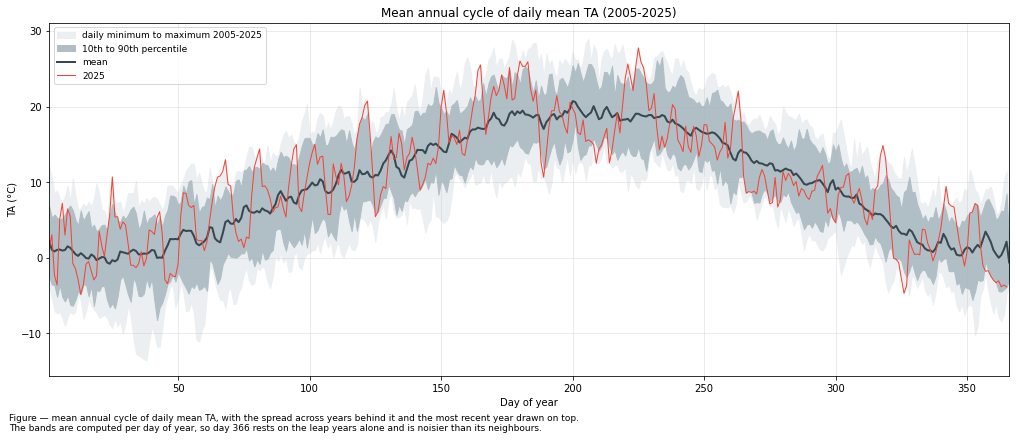

In [18]:
# Mean annual cycle of the daily mean, with the spread across years behind it and the most recent
# year drawn on top. The bands are computed per day of year, so day 366 rests on the leap years
# only and is noisier than its neighbours.
_doy = daily['mean'].groupby(daily.index.dayofyear)
_x = _doy.mean().index

fig, ax = plt.subplots(figsize=(14, 6), dpi=72, layout="constrained")
ax.fill_between(_x, _doy.min(), _doy.max(), color='#ECEFF1',
                label=f"daily minimum to maximum {FIRST_YEAR}-{LAST_YEAR}")
ax.fill_between(_x, _doy.quantile(0.1), _doy.quantile(0.9), color='#B0BEC5',
                label="10th to 90th percentile")
ax.plot(_x, _doy.mean(), color='#37474F', lw=2, label="mean")
_last_year = daily['mean'].loc[str(LAST_YEAR)]
ax.plot(_last_year.index.dayofyear, _last_year.to_numpy(), color='#F44336', lw=1, label=str(LAST_YEAR))
ax.set_xlabel("Day of year")
ax.set_ylabel(xlabel)
ax.set_title(f"Mean annual cycle of daily mean {var} ({FIRST_YEAR}-{LAST_YEAR})")
ax.set_xlim(1, 366)
ax.grid(alpha=0.3)
ax.legend(loc='upper left', fontsize=9)
figcap(fig, f"mean annual cycle of daily mean {var}, with the spread across years behind it and the "
            f"most recent year drawn on top. The bands are computed per day of year, so day 366 rests "
            f"on the leap years alone and is noisier than its neighbours.")
fig.show()

## Recent period against the earlier years, per month

In [19]:
# The two periods of the period means, resolved by calendar month: which months carry the
# difference between them. A difference here is not a trend estimate, it is the distance between
# two averages; the trends are further below.
_split = monthly_avg.index.max() - N_RECENT_YEARS + 1
_early_label = f"{monthly_avg.index.min()}-{_split - 1} ({units})"
_recent_label = f"{_split}-{monthly_avg.index.max()} ({units})"
_difference_label = f"difference ({units})"

comparison = pd.DataFrame({
    _early_label: monthly_avg.loc[:_split - 1].mean(),
    _recent_label: monthly_avg.loc[_split:].mean(),
})
comparison[_difference_label] = comparison[_recent_label] - comparison[_early_label]
comparison.index.name = "MONTH"

_styler = styled(comparison, caption=f"the two periods of the period means resolved by calendar month, with the "
                        f"difference between them. It shows which part of the year carries that "
                        f"difference; it is a distance between two averages, not a trend estimate",
                 subset=[_early_label, _recent_label])
display(anomaly_bars(_styler, _difference_label))

Table — the two periods of the period means resolved by calendar month, with the difference between
them. It shows which part of the year carries that difference; it is a distance between two
averages, not a trend estimate



,2005-2015 (°C),2016-2025 (°C),difference (°C)
MONTH,,,
Jan,0.1,0.8,0.7
Feb,0.3,3.2,2.9
Mar,4.7,6.0,1.4
Apr,9.7,9.4,-0.2
May,12.9,12.9,0.1
Jun,16.6,18.2,1.6
Jul,18.6,19.5,0.9
Aug,17.4,19.5,2.1
Sep,14.2,15.4,1.2


## Mean diurnal cycle per month

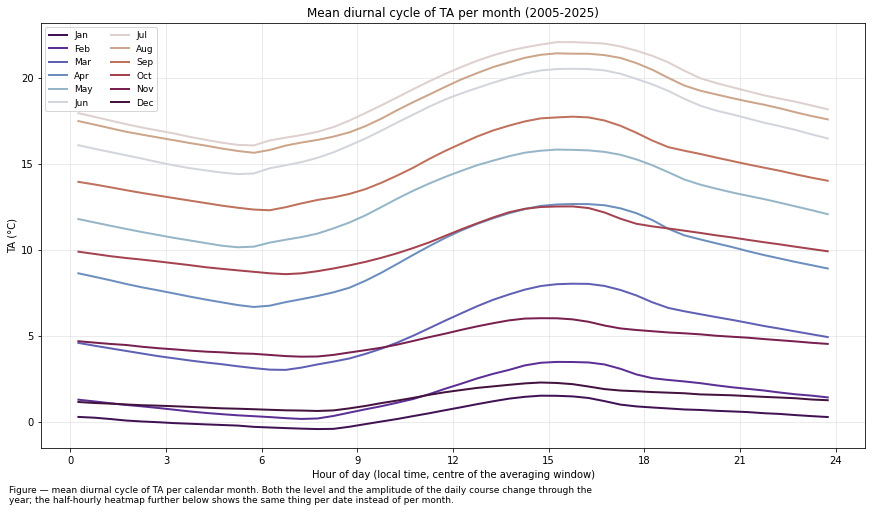

In [20]:
# Mean diurnal cycle per calendar month. The x axis is the centre of each 30MIN window, so the
# first point of the day is 00:15 and the last is 23:45.
_diurnal = series.groupby([series.index.month,
                           series.index.hour + series.index.minute / 60]).mean().unstack(0)

fig, ax = plt.subplots(figsize=(12, 7), dpi=72, layout="constrained")
_colors = plt.get_cmap('twilight_shifted')(np.linspace(0.05, 0.95, len(_diurnal.columns)))
for _i, _month in enumerate(_diurnal.columns):
    ax.plot(_diurnal.index, _diurnal[_month], color=_colors[_i], lw=2,
            label=calendar.month_abbr[_month])
ax.set_xlabel("Hour of day (local time, centre of the averaging window)")
ax.set_ylabel(xlabel)
ax.set_title(f"Mean diurnal cycle of {var} per month ({FIRST_YEAR}-{LAST_YEAR})")
ax.set_xticks(range(0, 25, 3))
ax.grid(alpha=0.3)
ax.legend(ncol=2, fontsize=9)
figcap(fig, f"mean diurnal cycle of {var} per calendar month. Both the level and the amplitude of the "
            f"daily course change through the year; the half-hourly heatmap further below shows the "
            f"same thing per date instead of per month.")
fig.show()

## Month by hour

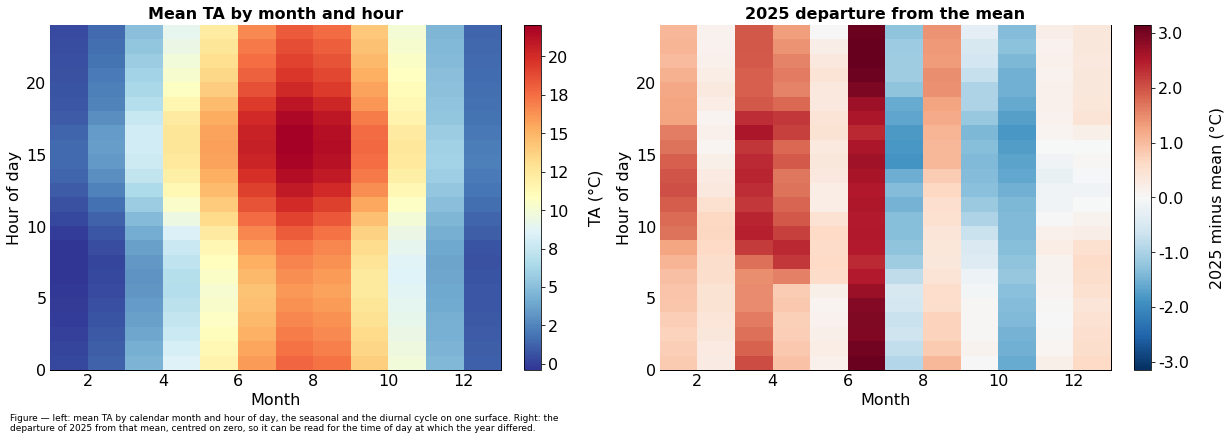

In [21]:
# The same cycle as a surface, next to the departure of the most recent year from it. The right
# panel is centred on zero, so red and blue are equal distances from the long-term mean.
def _by_month_hour(s):
    """Mean of `s` per calendar month and hour, in the long form HeatmapXYZ expects."""
    frame = pd.DataFrame({'MONTH': s.index.month, 'HOUR': s.index.hour, 'z': s.to_numpy()})
    return frame.groupby(['MONTH', 'HOUR'], as_index=False)['z'].mean()


_clim_hm = _by_month_hour(series)
_last_hm = _by_month_hour(series.loc[str(LAST_YEAR)])
_anomaly_hm = _clim_hm.copy()
_anomaly_hm['z'] = _last_hm['z'].to_numpy() - _clim_hm['z'].to_numpy()
_absmax = _anomaly_hm['z'].abs().max()

fig, axs = plt.subplots(ncols=2, figsize=(17, 6), dpi=72, layout="constrained")
dv.plotting.HeatmapXYZ(x=_clim_hm['MONTH'], y=_clim_hm['HOUR'], z=_clim_hm['z']).plot(
    ax=axs[0], cb_digits_after_comma=0,
    xlabel="Month", ylabel="Hour of day", zlabel=f"{var} ({units})",
    format_style=dv.plotting.FormatStyle(title=f"Mean {var} by month and hour"))
dv.plotting.HeatmapXYZ(x=_anomaly_hm['MONTH'], y=_anomaly_hm['HOUR'], z=_anomaly_hm['z']).plot(
    ax=axs[1], cmap='RdBu_r', vmin=-_absmax, vmax=_absmax, cb_digits_after_comma=1,
    xlabel="Month", ylabel="Hour of day", zlabel=f"{LAST_YEAR} minus mean ({units})",
    format_style=dv.plotting.FormatStyle(title=f"{LAST_YEAR} departure from the mean"))
figcap(fig, f"left: mean {var} by calendar month and hour of day, the seasonal and the diurnal cycle "
            f"on one surface. Right: the departure of {LAST_YEAR} from that mean, centred on zero, so "
            f"it can be read for the time of day at which the year differed.")

</br>

# Extremes and threshold days

::: {.callout-warning title="Not comparable across January 2016"}

The homogenisation corrects the level of the earlier era, not the shape of its daily cycle. The
two sensors had different radiation shields, and that difference acts in daylight: daily minima
carry a residual step of roughly +0.2 °C at the break, but **daily maxima and diurnal ranges carry
about +0.7 to +0.8 °C**.

Everything in this section that is built on a daily maximum — summer days, hot days, warm spells,
new record highs — therefore remains inhomogeneous across 2016 in both columns. A count from 2020
is not comparable with one from 2010, and the apparent increase in the warm indices is in part the
sensor. Frost days, ice days and the growing season rest on daily minima and daily means and are
much less affected.

:::


## Highest and lowest half-hourly value

In [22]:
# Extremes come from the measured records only (see About). The averaging window is reported
# instead of the timestamp, because the product is stored on TIMESTAMP_MIDDLE.
for _label, _tsmid in [("Highest", series_measured.idxmax()), ("Lowest", series_measured.idxmin())]:
    print(f"{_label} measured {var}: {series_measured.loc[_tsmid]:.1f} {units} ({window(_tsmid)})")

# A gap-filled value outside the measured range would be quoted as a record by anyone reading the
# full series, so the two ranges are compared rather than left to be discovered.
if (series.max() > series_measured.max()) or (series.min() < series_measured.min()):
    print(f"Note: the full series reaches {series.min():.1f} to {series.max():.1f} {units}, "
          f"outside the measured range. Those values are model results.")
else:
    print("The gap-filled values stay inside the measured range.")

Highest measured TA: 34.0 °C (07 Aug 2015, 17:00 to 17:30)
Lowest measured TA: -15.9 °C (07 Feb 2012, 04:30 to 05:00)
The gap-filled values stay inside the measured range.


## The warmest and coldest half-hours

In [23]:
# The extremes above in context. Neighbouring half-hours of the same afternoon fill these lists,
# which is the point: a record half-hour is part of an episode, not an isolated reading.
for _label, _ranked in [("warmest", series_measured.nlargest(N_EXTREMES)),
                        ("coldest", series_measured.nsmallest(N_EXTREMES))]:
    _table = pd.DataFrame({"averaging window": [window(_ts) for _ts in _ranked.index],
                           f"{var} ({units})": _ranked.to_numpy()},
                          index=range(1, N_EXTREMES + 1))
    _table.index.name = "rank"
    display(styled(_table, caption=f"the {N_EXTREMES} {_label} measured half-hours with their averaging "
                           f"windows. Neighbouring windows of a single afternoon fill the list, "
                           f"which is what an episode looks like at this resolution",
                   subset=[f"{var} ({units})"]))

Table — the 10 warmest measured half-hours with their averaging windows. Neighbouring windows of a
single afternoon fill the list, which is what an episode looks like at this resolution



,averaging window,TA (°C)
rank,,
1,"07 Aug 2015, 17:00 to 17:30",34.0
2,"07 Aug 2015, 16:30 to 17:00",33.9
3,"07 Aug 2015, 16:00 to 16:30",33.7
4,"04 Aug 2022, 16:30 to 17:00",33.6
5,"04 Aug 2022, 17:00 to 17:30",33.5
6,"07 Aug 2015, 17:30 to 18:00",33.5
7,"04 Aug 2022, 16:00 to 16:30",33.5
8,"25 Jul 2019, 15:30 to 16:00",33.4
9,"07 Jul 2015, 15:30 to 16:00",33.4


Table — the 10 coldest measured half-hours with their averaging windows. Neighbouring windows of a
single afternoon fill the list, which is what an episode looks like at this resolution



,averaging window,TA (°C)
rank,,
1,"07 Feb 2012, 04:30 to 05:00",-15.9
2,"06 Feb 2012, 07:30 to 08:00",-15.8
3,"07 Feb 2012, 04:00 to 04:30",-15.8
4,"06 Feb 2012, 07:00 to 07:30",-15.8
5,"06 Feb 2012, 08:00 to 08:30",-15.8
6,"07 Feb 2012, 05:00 to 05:30",-15.7
7,"07 Feb 2012, 02:00 to 02:30",-15.7
8,"06 Feb 2012, 06:30 to 07:00",-15.6
9,"05 Feb 2012, 07:30 to 08:00",-15.6


## The warmest and coldest days

In [24]:
# The same for daily means. A daily mean is computed over all records of the day, gap-filled ones
# included, so the filled share is listed next to it.
for _label, _ranked in [("warmest", daily['mean'].nlargest(N_EXTREMES)),
                        ("coldest", daily['mean'].nsmallest(N_EXTREMES))]:
    _table = pd.DataFrame({"date": [f"{_day:%d %b %Y}" for _day in _ranked.index],
                           f"daily mean {var} ({units})": _ranked.to_numpy(),
                           "gap-filled (%)": daily.loc[_ranked.index, 'gap-filled (%)'].to_numpy()},
                          index=range(1, N_EXTREMES + 1))
    _table.index.name = "rank"
    display(styled(_table, caption=f"the {N_EXTREMES} {_label} days by daily mean, with the share of each day "
                           f"that was gap-filled. A day with a large filled share is a model "
                           f"result as much as a measurement",
                   subset=[f"daily mean {var} ({units})"]))

Table — the 10 warmest days by daily mean, with the share of each day that was gap-filled. A day
with a large filled share is a model result as much as a measurement



,date,daily mean TA (°C),gap-filled (%)
rank,,,
1,25 Jul 2019,29.0,0.0
2,26 Jun 2019,28.9,0.0
3,05 Jul 2015,28.4,0.0
4,24 Jul 2019,28.4,0.0
5,04 Jul 2015,28.4,0.0
6,04 Aug 2022,28.3,0.0
7,07 Aug 2015,28.2,0.0
8,27 Jul 2013,28.2,0.0
9,27 Jun 2019,28.1,0.0


Table — the 10 coldest days by daily mean, with the share of each day that was gap-filled. A day
with a large filled share is a model result as much as a measurement



,date,daily mean TA (°C),gap-filled (%)
rank,,,
1,07 Feb 2012,-13.6,0.0
2,06 Feb 2012,-13.4,0.0
3,05 Feb 2012,-13.2,0.0
4,04 Feb 2012,-12.9,0.0
5,03 Feb 2012,-12.7,2.1
6,12 Feb 2012,-11.8,0.0
7,11 Feb 2012,-11.7,0.0
8,27 Feb 2018,-11.1,0.0
9,08 Feb 2012,-11.1,0.0


## Number of days below 0°C

Table — days per year with a daily minimum TA below 0 °C, the counts behind the bar chart in this
section



,days
YEAR,
2005,105
2006,88
2007,58
2008,79
2009,83
2010,96
2011,53
2012,66
2013,100


Average per year: 71.2 +/- 17.88 SD


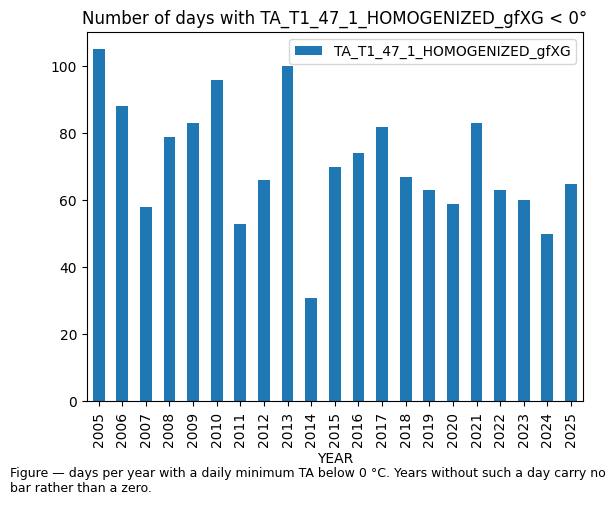

In [25]:
plotdf = df[[varname]].copy()
plotdf = plotdf.resample('D').min()
belowzero = plotdf.loc[plotdf[varname] < 0].copy()
belowzero = belowzero.groupby(belowzero.index.year).count()
belowzero["YEAR"] = belowzero.index
_ax = belowzero.plot.bar(x="YEAR", y=varname, title=f"Number of days with {varname} < 0°")
figcap(_ax.get_figure(), f"days per year with a daily minimum {var} below 0 {units}. Years without "
                         f"such a day carry no bar rather than a zero.")

_table = belowzero[[varname]].rename(columns={varname: "days"})
_table.index.name = "YEAR"
display(styled(_table, caption=f"days per year with a daily minimum {var} below 0 {units}, the counts behind "
                       f"the bar chart in this section",
               fmt="{:.0f}", cmap="Blues"))
print(f"Average per year: {belowzero[varname].mean():.1f} +/- {belowzero[varname].std():.2f} SD")

## Number of days above 30°C

Table — days per year with a daily maximum TA above 30 °C, the counts behind the bar chart in this
section



,days
YEAR,
2005,5
2006,6
2007,2
2009,3
2010,4
2011,4
2012,3
2013,5
2014,4


Average per year: 5.8 +/- 2.90 SD


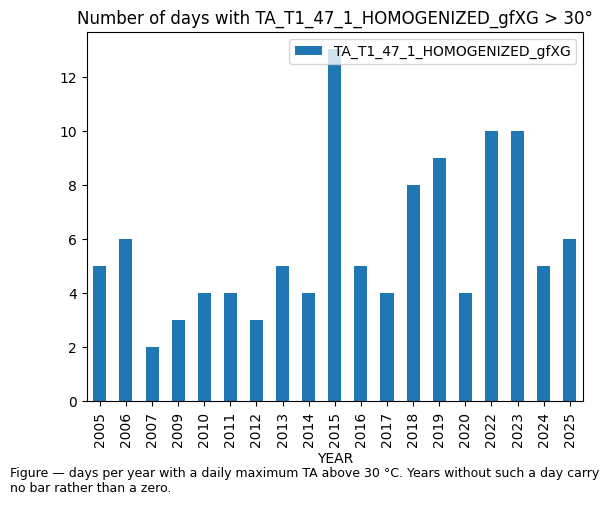

In [26]:
plotdf = df[[varname]].copy()
plotdf = plotdf.resample('D').max()
above = plotdf.loc[plotdf[varname] > 30].copy()
above = above.groupby(above.index.year).count()
above["YEAR"] = above.index
_ax = above.plot.bar(x="YEAR", y=varname, title=f"Number of days with {varname} > 30°")
figcap(_ax.get_figure(), f"days per year with a daily maximum {var} above 30 {units}. Years without "
                         f"such a day carry no bar rather than a zero.")

_table = above[[varname]].rename(columns={varname: "days"})
_table.index.name = "YEAR"
display(styled(_table, caption=f"days per year with a daily maximum {var} above 30 {units}, the counts behind "
                       f"the bar chart in this section",
               fmt="{:.0f}", cmap="Reds"))
print(f"Average per year: {above[varname].mean():.1f} +/- {above[varname].std():.2f} SD")

## Threshold days

Table — threshold days per year for the five standard indices, each with its threshold in the column
name. The counts come from daily minima and maxima of the full series, gap-filled records included



,frost days (min < 0),ice days (max < 0),summer days (max >= 25),hot days (max >= 30),tropical nights (min >= 20)
YEAR,,,,,
2005,105,53,26,5,9
2006,88,42,35,6,9
2007,58,22,18,2,2
2008,79,19,17,0,1
2009,83,37,29,3,3
2010,96,55,26,4,2
2011,53,21,24,4,4
2012,66,30,21,3,4
2013,100,37,32,5,8


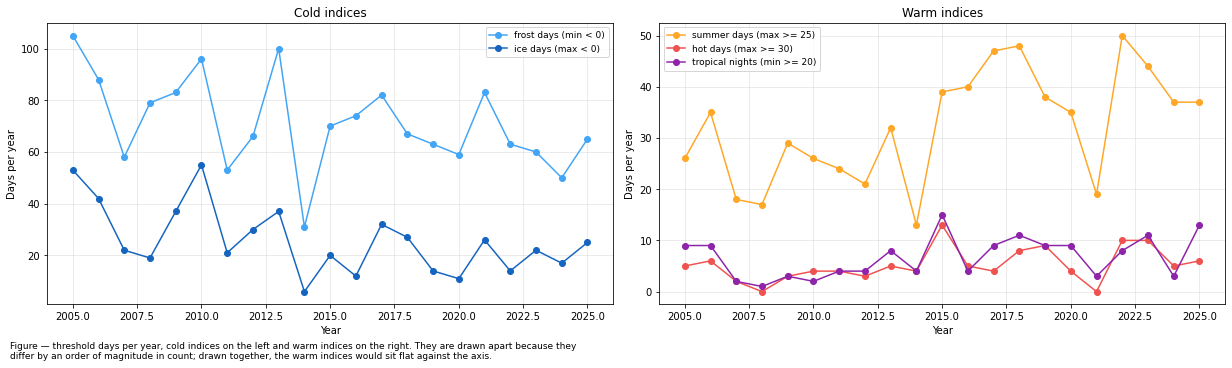

In [27]:
# The standard threshold-day counts. The two sections above are two of these; the set is listed
# together so that a year can be read in one row. Thresholds are the usual ones and are stated in
# the column names, because the counts mean nothing without them.
indices = pd.DataFrame({
    "frost days (min < 0)": per_year(daily['min'].lt(0).astype(float), 'sum'),
    "ice days (max < 0)": per_year(daily['max'].lt(0).astype(float), 'sum'),
    "summer days (max >= 25)": per_year(daily['max'].ge(25).astype(float), 'sum'),
    "hot days (max >= 30)": per_year(daily['max'].ge(30).astype(float), 'sum'),
    "tropical nights (min >= 20)": per_year(daily['min'].ge(20).astype(float), 'sum'),
})
display(styled(indices, caption="threshold days per year for the five standard indices, each with its threshold in the column name. The counts come from daily minima and maxima of the full series, gap-filled records included", fmt="{:.0f}", cmap="RdYlBu_r"))

# Cold and warm indices are drawn apart because they differ by an order of magnitude in count.
fig, axs = plt.subplots(ncols=2, figsize=(17, 5), dpi=72, layout="constrained")
indices[["frost days (min < 0)", "ice days (max < 0)"]].plot(ax=axs[0], marker='o', lw=1.5,
                                                             color=['#42A5F5', '#1565C0'])
indices[["summer days (max >= 25)", "hot days (max >= 30)",
         "tropical nights (min >= 20)"]].plot(ax=axs[1], marker='o', lw=1.5,
                                              color=['#FFA726', '#EF5350', '#8E24AA'])
for _ax, _title in [(axs[0], "Cold indices"), (axs[1], "Warm indices")]:
    _ax.set_title(_title)
    _ax.set_xlabel("Year")
    _ax.set_ylabel("Days per year")
    _ax.grid(alpha=0.3)
    _ax.legend(fontsize=9)
figcap(fig, "threshold days per year, cold indices on the left and warm indices on the right. They "
            "are drawn apart because they differ by an order of magnitude in count; drawn together, "
            "the warm indices would sit flat against the axis.")

## Growing season

Table — growing season per year on a 5 °C base: start, end, length and growing degree days. The
definition is the one in `growing_season` and the numbers only compare against numbers computed the
same way



,start,end,length (days),start (day of year),end (day of year),growing degree days (°C d)
YEAR,,,,,,
2005,15 Mar,13 Nov,243,74,317,2142
2006,30 Mar,09 Dec,254,89,343,2240
2007,07 Jan,19 Oct,285,7,292,2074
2008,22 Feb,13 Nov,265,53,318,1920
2009,13 Mar,14 Oct,215,72,287,2196
2010,17 Mar,16 Oct,213,76,289,1943
2011,09 Mar,23 Nov,259,68,327,2274
2012,28 Feb,13 Nov,259,59,318,2118
2013,05 Mar,10 Nov,250,64,314,1979


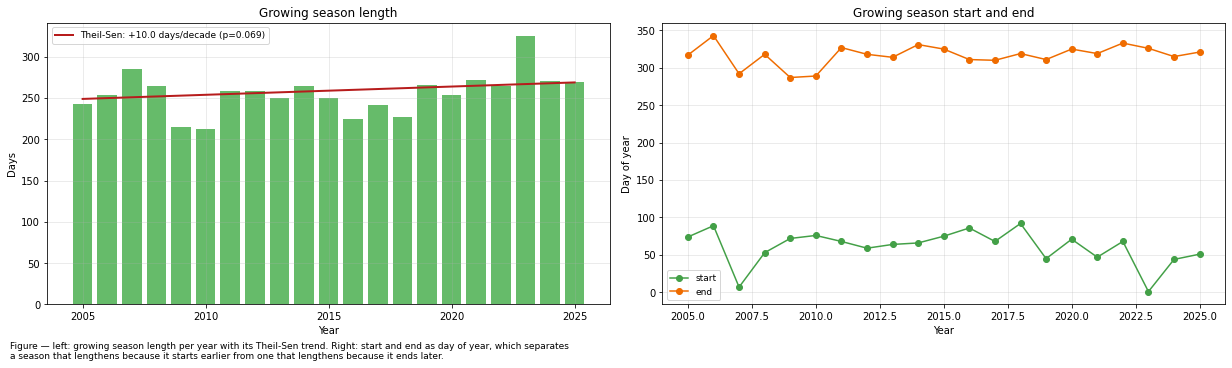

In [28]:
# Growing season and growing degree days per year, both on a 5 °C base. See `growing_season` for
# the definition; it is one convention among several and the numbers are only comparable to
# numbers computed the same way.
BASE = 5.0

_rows = {}
for _year, _daily_mean in daily['mean'].groupby(daily.index.year):
    _season = growing_season(_daily_mean, base=BASE)
    if _season is None:
        continue
    _rows[_year] = {"start": f"{_season['start']:%d %b}",
                    "end": f"{_season['end']:%d %b}",
                    "length (days)": _season['length'],
                    "start (day of year)": _season['start'].dayofyear,
                    "end (day of year)": _season['end'].dayofyear}
season = pd.DataFrame.from_dict(_rows, orient='index')
season.index.name = "YEAR"
season["growing degree days (°C d)"] = per_year((daily['mean'] - BASE).clip(lower=0), 'sum')

_fmt = "{:.0f}"
display(styled(season, caption=f"growing season per year on a {BASE:.0f} {units} base: start, end, length and "
                       f"growing degree days. The definition is the one in `growing_season` and "
                       f"the numbers only compare against numbers computed the same way", fmt=_fmt,
               subset=["length (days)", "growing degree days (°C d)"], cmap="YlGn"))

fig, axs = plt.subplots(ncols=2, figsize=(17, 5), dpi=72, layout="constrained")
axs[0].bar(season.index, season["length (days)"], color='#66BB6A')
_fit = trend(season["length (days)"].astype(float))
axs[0].plot(_fit['fit'].index, _fit['fit'], color='#B71C1C', lw=2,
            label=f"Theil-Sen: {_fit['slope']:+.1f} days/decade (p={_fit['pvalue']:.3f})")
axs[0].set_title("Growing season length")
axs[0].set_ylabel("Days")
axs[0].legend(fontsize=9)
axs[1].plot(season.index, season["start (day of year)"], marker='o', color='#43A047',
            label="start")
axs[1].plot(season.index, season["end (day of year)"], marker='o', color='#EF6C00', label="end")
axs[1].set_title("Growing season start and end")
axs[1].set_ylabel("Day of year")
axs[1].legend(fontsize=9)
for _ax in axs:
    _ax.set_xlabel("Year")
    _ax.grid(alpha=0.3)
figcap(fig, "left: growing season length per year with its Theil-Sen trend. Right: start and end as "
            "day of year, which separates a season that lengthens because it starts earlier from one "
            "that lengthens because it ends later.")

## Warm and cold spells

In [29]:
# The longest warm and cold spells of each year: how long a threshold was held without a break,
# and when the spell started. A year can reach a high count of summer days without ever holding
# one for a week, and the two say different things about the season.
_rows = {}
for _year, _day in daily.groupby(daily.index.year):
    _warm_len, _warm_start = longest_spell(_day['max'].ge(25))
    _frost_len, _frost_start = longest_spell(_day['min'].lt(0))
    _rows[_year] = {"warm spell (days)": _warm_len,
                    "warm spell start": "-" if pd.isna(_warm_start) else f"{_warm_start:%d %b}",
                    "frost spell (days)": _frost_len,
                    "frost spell start": "-" if pd.isna(_frost_start) else f"{_frost_start:%d %b}"}
spells = pd.DataFrame.from_dict(_rows, orient='index')
spells.index.name = "YEAR"

display(styled(spells, caption="the longest uninterrupted warm and frost spell of each year with its start "
                               "date. A year can collect many summer days without ever holding "
                               "one for a week, which the counts above cannot show",
               fmt="{:.0f}", cmap="RdYlBu_r"))

Table — the longest uninterrupted warm and frost spell of each year with its start date. A year can
collect many summer days without ever holding one for a week, which the counts above cannot show



,warm spell (days),warm spell start,frost spell (days),frost spell start
YEAR,,,,
2005,6,19 Jun,30,13 Feb
2006,19,10 Jul,24,22 Jan
2007,4,13 Jul,17,13 Dec
2008,5,21 Jun,13,21 Nov
2009,7,15 Aug,18,01 Jan
2010,8,26 Jun,16,01 Jan
2011,10,17 Aug,17,19 Jan
2012,5,18 Aug,27,28 Jan
2013,13,16 Jul,31,02 Feb


## New records per year

Read forwards: a record is a record against what came before it, not against the whole dataset.
Note that record **highs** are subject to the daytime inhomogeneity described at the head of this
section, so their apparent concentration in the later years is partly the change of sensor. Record
lows rest on daily minima and are much less affected.


Table — days that set a new record against everything measured before them, counted per year from
2006. Records necessarily thin out as the record grows, so a late year holding several is the
notable case



,new record highs,new record lows
YEAR,,
2006,0,0
2007,0,0
2008,0,0
2009,0,2
2010,1,0
2011,0,0
2012,0,4
2013,1,0
2014,0,0


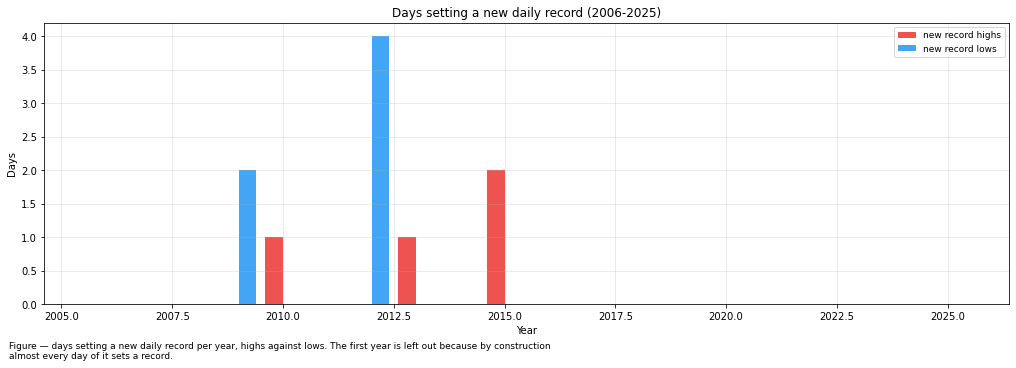

In [30]:
# Days that set a new record for the record so far, counted per year. The first year is left out:
# by construction almost every day of it sets a record, which would swamp the plot. Reading this
# forwards only is the point - a record is a record against what came before it, not against the
# whole dataset.
_running_high = daily_measured['max'].shift().cummax()
_running_low = daily_measured['min'].shift().cummin()
_new_high = daily_measured['max'] > _running_high
_new_low = daily_measured['min'] < _running_low

records = pd.DataFrame({
    "new record highs": per_year(_new_high.astype(float), 'sum'),
    "new record lows": per_year(_new_low.astype(float), 'sum'),
}).loc[FIRST_YEAR + 1:]

display(styled(records, caption=f"days that set a new record against everything measured before them, counted "
                       f"per year from {FIRST_YEAR + 1}. Records necessarily thin out as the "
                       f"record grows, so a late year holding several is the notable case",
               fmt="{:.0f}", cmap="RdYlBu_r"))

fig, ax = plt.subplots(figsize=(14, 5), dpi=72, layout="constrained")
ax.bar(records.index - 0.2, records["new record highs"], width=0.4, color='#EF5350',
       label="new record highs")
ax.bar(records.index + 0.2, records["new record lows"], width=0.4, color='#42A5F5',
       label="new record lows")
ax.set_xlabel("Year")
ax.set_ylabel("Days")
ax.set_title(f"Days setting a new daily record ({FIRST_YEAR + 1}-{LAST_YEAR})")
ax.grid(alpha=0.3)
ax.legend(fontsize=9)
figcap(fig, f"days setting a new daily record per year, highs against lows. The first year is left "
            f"out because by construction almost every day of it sets a record.")
fig.show()

</br>

# Distributions

Ridgeline plots of the half-hourly values, then the same distributions read as percentiles.

## Ridgelines per year

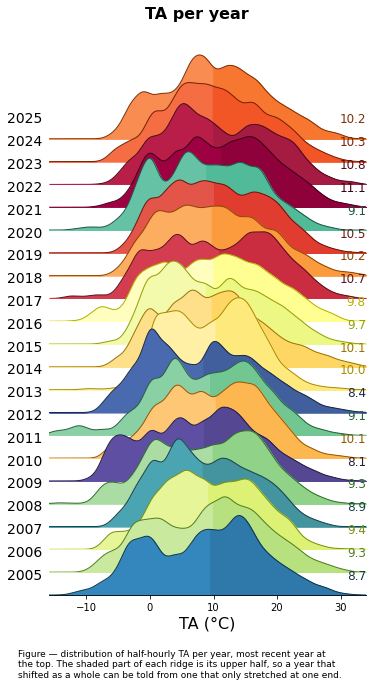

In [31]:
rp = dv.plotting.RidgeLinePlot(series=series)
rp.plot(
    how='yearly',
    kd_kwargs=None,  # params from scikit KernelDensity as dict
    xlim=xlim,  # min/max as list
    ylim=[0, 0.07],  # min/max as list
    hspace=-0.8,  # overlap between months
    fig_width=5,
    fig_height=9,
    shade_percentile=0.5,
    show_mean_line=False,
    format_style=dv.plotting.FormatStyle(xlabel=xlabel, title=f"{var} per year"),
    fig_dpi=72,
    showplot=True,
    ascending=False
)
figcap(rp.fig, f"distribution of half-hourly {var} per year, most recent year at the top. The shaded "
               f"part of each ridge is its upper half, so a year that shifted as a whole can be told "
               f"from one that only stretched at one end.")

## Ridgelines per month

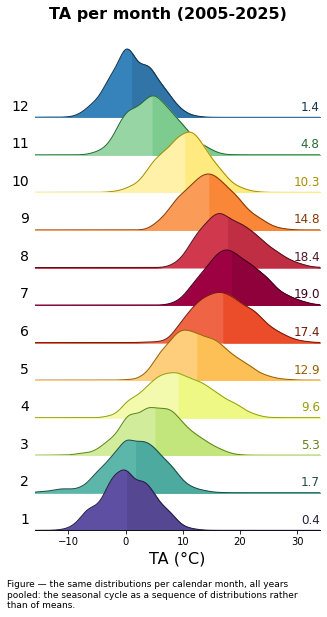

In [32]:
rp.plot(
    how='monthly',
    kd_kwargs=None,  # params from scikit KernelDensity as dict
    xlim=xlim,  # min/max as list
    ylim=[0, 0.14],  # min/max as list
    hspace=-0.6,  # overlap between months
    fig_width=4.5,
    fig_height=8,
    shade_percentile=0.5,
    show_mean_line=False,
    format_style=dv.plotting.FormatStyle(xlabel=xlabel,
                                         title=f"{var} per month ({FIRST_YEAR}-{LAST_YEAR})"),
    fig_dpi=72,
    showplot=True,
    ascending=False
)
figcap(rp.fig, f"the same distributions per calendar month, all years pooled: the seasonal cycle as a "
               f"sequence of distributions rather than of means.")

## Ridgelines per week

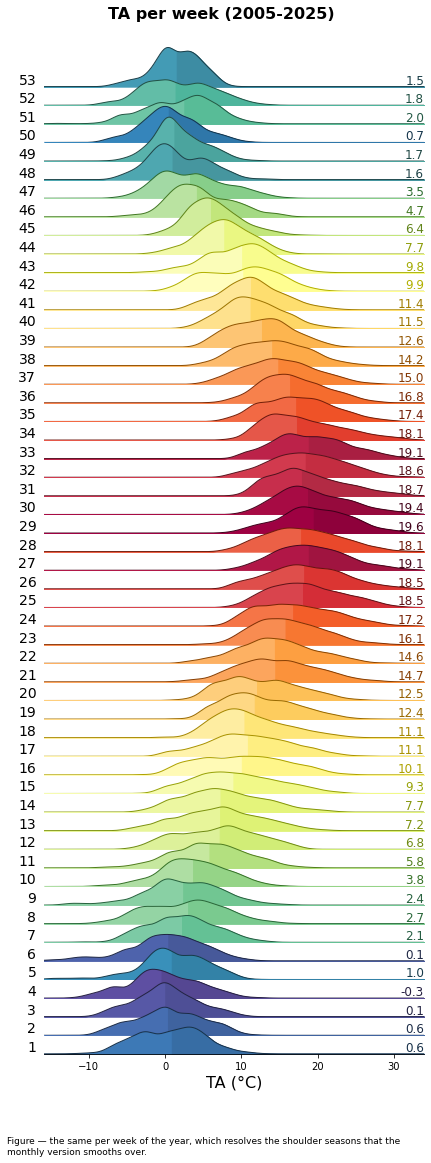

In [33]:
rp.plot(
    how='weekly',
    kd_kwargs=None,  # params from scikit KernelDensity as dict
    xlim=xlim,  # min/max as list
    ylim=[0, 0.15],  # min/max as list
    hspace=-0.6,  # overlap
    fig_width=6,
    fig_height=16,
    shade_percentile=0.5,
    show_mean_line=False,
    format_style=dv.plotting.FormatStyle(xlabel=xlabel,
                                         title=f"{var} per week ({FIRST_YEAR}-{LAST_YEAR})"),
    fig_dpi=72,
    showplot=True,
    ascending=False
)
figcap(rp.fig, f"the same per week of the year, which resolves the shoulder seasons that the monthly "
               f"version smooths over.")

## Percentiles per year

Table — percentiles of half-hourly TA per year, the numbers behind the bands: whether a year moved
as a whole or only at one end



,5th percentile (°C),25th percentile (°C),50th percentile (°C),75th percentile (°C),95th percentile (°C)
YEAR,,,,,
2005,-4.9,1.1,9.4,15.1,22.6
2006,-4.6,2.0,9.9,15.7,23.2
2007,-2.9,3.8,9.1,15.3,21.7
2008,-2.2,3.2,8.3,14.6,21.5
2009,-5.0,2.4,9.8,15.9,22.3
2010,-5.8,1.2,8.5,14.4,22.3
2011,-2.2,4.2,10.3,16.0,22.1
2012,-4.3,3.2,9.4,15.4,22.1
2013,-3.9,1.1,8.4,14.8,22.9


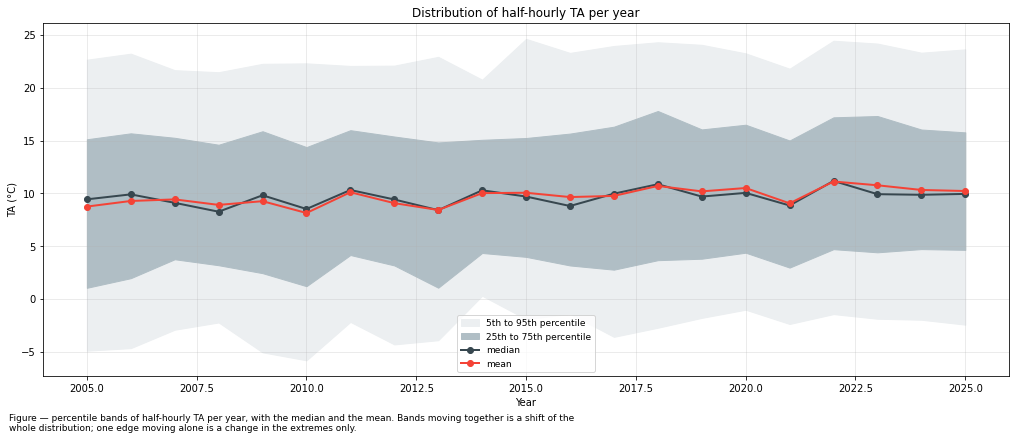

In [34]:
# Quantiles of the half-hourly values per year. The ridgelines above show the shape of each year's
# distribution; this shows where its edges moved. A shift of the median with unchanged 5th and 95th
# percentiles is a different signal from a spread that widens at one end only.
QUANTILES = [0.05, 0.25, 0.5, 0.75, 0.95]
quantiles = series.groupby(series.index.year).quantile(QUANTILES).unstack()
quantiles.index.name = "YEAR"

fig, ax = plt.subplots(figsize=(14, 6), dpi=72, layout="constrained")
ax.fill_between(quantiles.index, quantiles[0.05], quantiles[0.95], color='#ECEFF1',
                label="5th to 95th percentile")
ax.fill_between(quantiles.index, quantiles[0.25], quantiles[0.75], color='#B0BEC5',
                label="25th to 75th percentile")
ax.plot(quantiles.index, quantiles[0.5], color='#37474F', lw=2, marker='o', label="median")
ax.plot(ym.index, ym, color='#F44336', lw=2, marker='o', label="mean")
ax.set_xlabel("Year")
ax.set_ylabel(xlabel)
ax.set_title(f"Distribution of half-hourly {var} per year")
ax.grid(alpha=0.3)
ax.legend(fontsize=9)
figcap(fig, f"percentile bands of half-hourly {var} per year, with the median and the mean. Bands "
            f"moving together is a shift of the whole distribution; one edge moving alone is a change "
            f"in the extremes only.")
fig.show()

_table = quantiles.copy()
_table.columns = [f"{int(q * 100)}th percentile ({units})" for q in _table.columns]
display(styled(_table, caption=f"percentiles of half-hourly {var} per year, the numbers behind the bands: "
                       f"whether a year moved as a whole or only at one end", axis=None))

</br>

# Heatmap plots

## Half-hourly

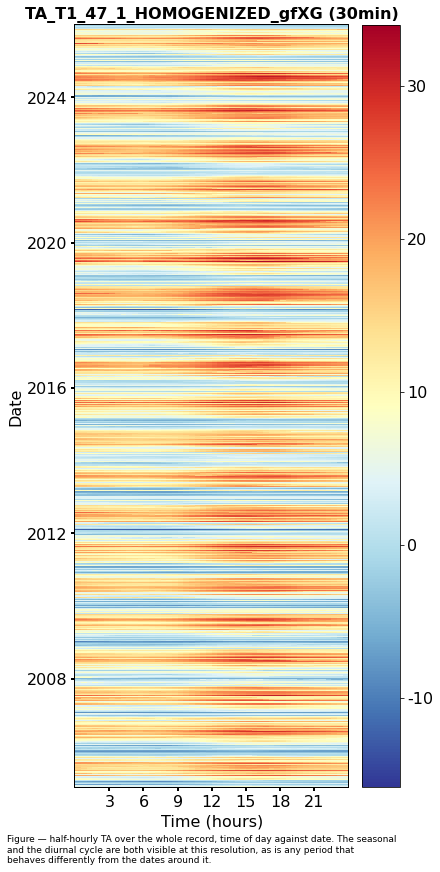

In [35]:
fig, axs = plt.subplots(ncols=1, figsize=(6, 12), dpi=72, layout="constrained")
dv.plotting.HeatmapDateTime(series=series).plot(ax=axs, cb_digits_after_comma=0)
figcap(fig, f"half-hourly {var} over the whole record, time of day against date. The seasonal and the "
            f"diurnal cycle are both visible at this resolution, as is any period that behaves "
            f"differently from the dates around it.")

## Monthly

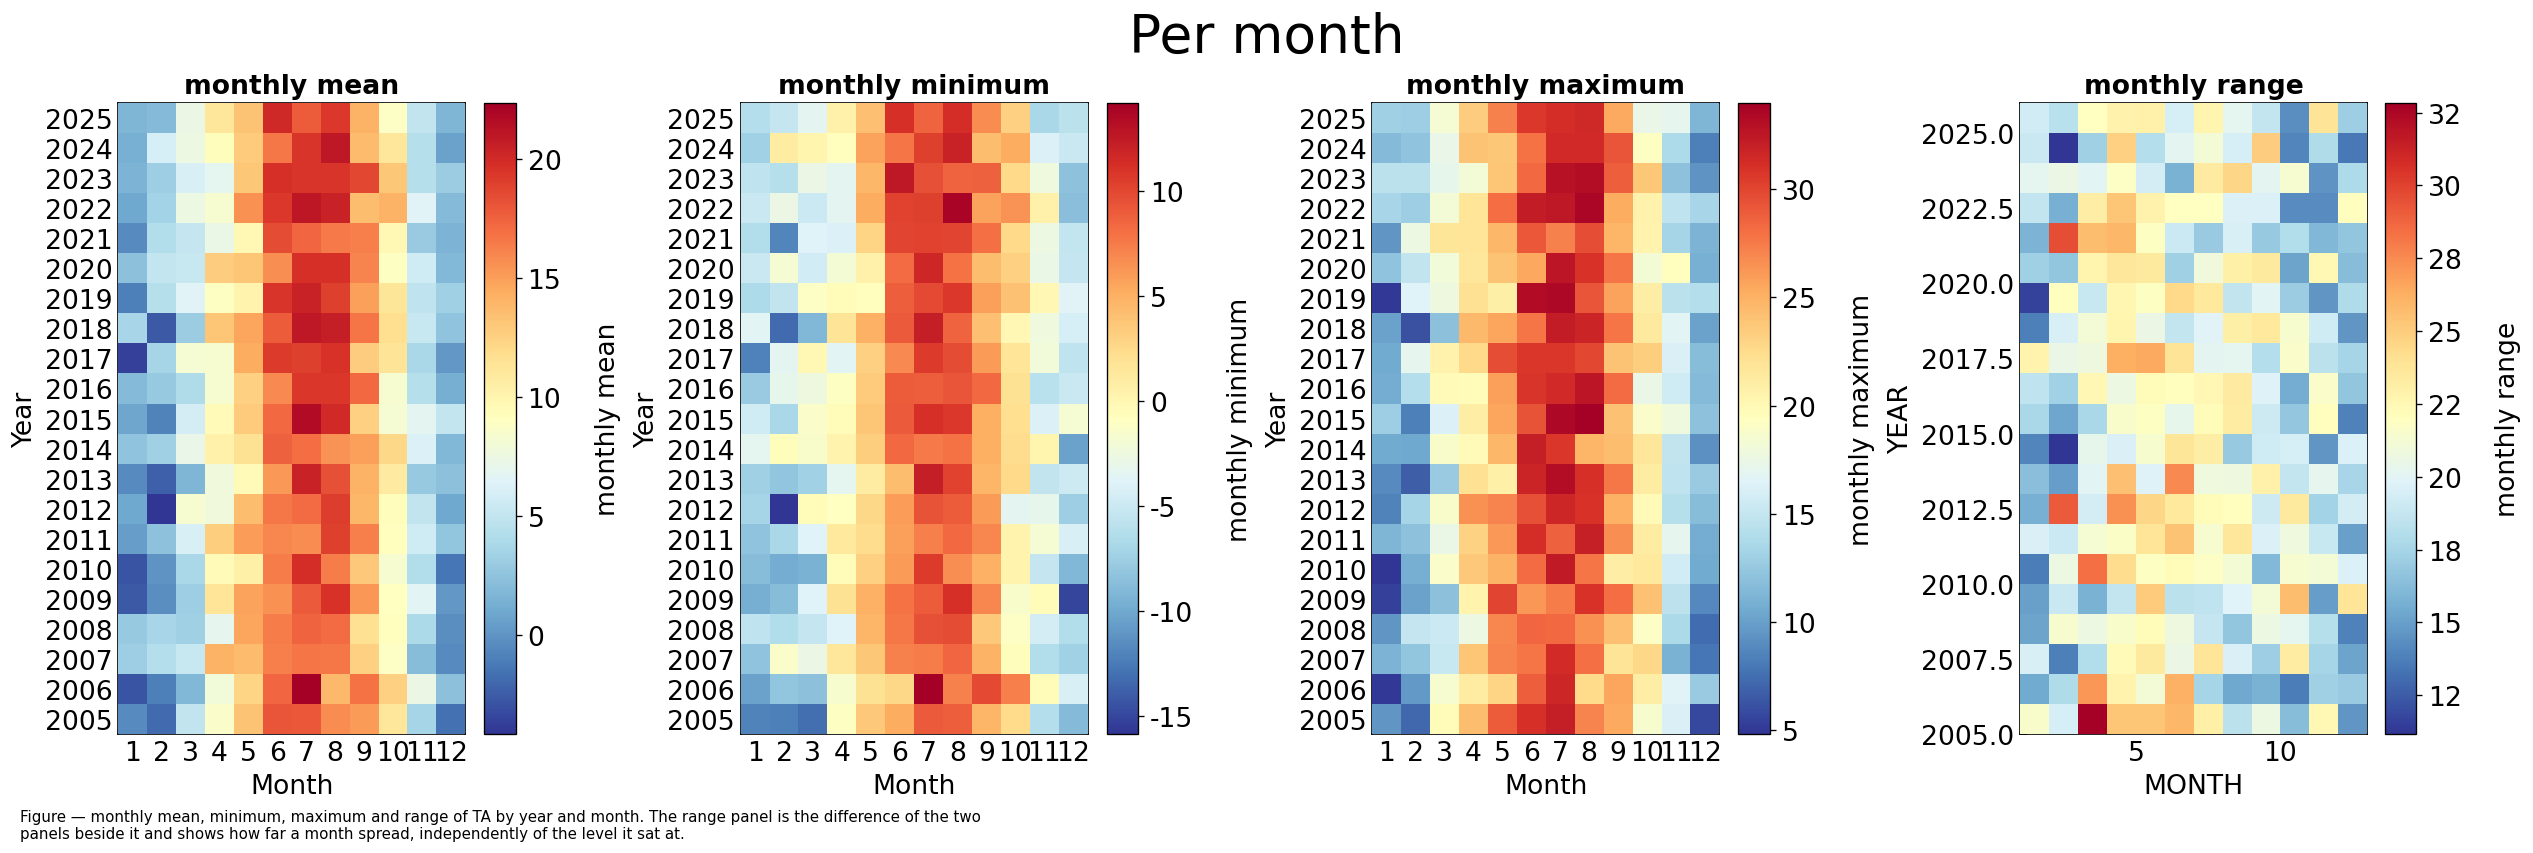

In [36]:
fig, axs = plt.subplots(ncols=4, figsize=(21, 7), dpi=120, layout="constrained")
fig.suptitle(f'Per month', fontsize=32)

# HeatmapYearMonth aggregates the half-hourly series itself, so it is passed unresampled.
for _ax, _agg, _label in [(axs[0], 'mean', "monthly mean"),
                          (axs[1], 'min', "monthly minimum"),
                          (axs[2], 'max', "monthly maximum")]:
    dv.plotting.HeatmapYearMonth(series=series, agg=_agg).plot(
        ax=_ax, cb_digits_after_comma=0, zlabel=_label,
        format_style=dv.plotting.FormatStyle(title=_label))

# There is no 'range' aggregation, so the range is computed from the max and min year-month
# matrices and drawn on the same grid with HeatmapXYZ.
_range = (dv.plotting.HeatmapYearMonth(series=series, agg='max').get_plot_data()
          - dv.plotting.HeatmapYearMonth(series=series, agg='min').get_plot_data())
_range_lf = _range.stack().rename("monthly range").reset_index()
dv.plotting.HeatmapXYZ(x=_range_lf['MONTH'], y=_range_lf['YEAR'], z=_range_lf["monthly range"]).plot(
    ax=axs[3], cb_digits_after_comma=0, zlabel="monthly range",
    format_style=dv.plotting.FormatStyle(title="monthly range"))
figcap(fig, f"monthly mean, minimum, maximum and range of {var} by year and month. The range panel is "
            f"the difference of the two panels beside it and shows how far a month spread, "
            f"independently of the level it sat at.")

## Monthly ranks

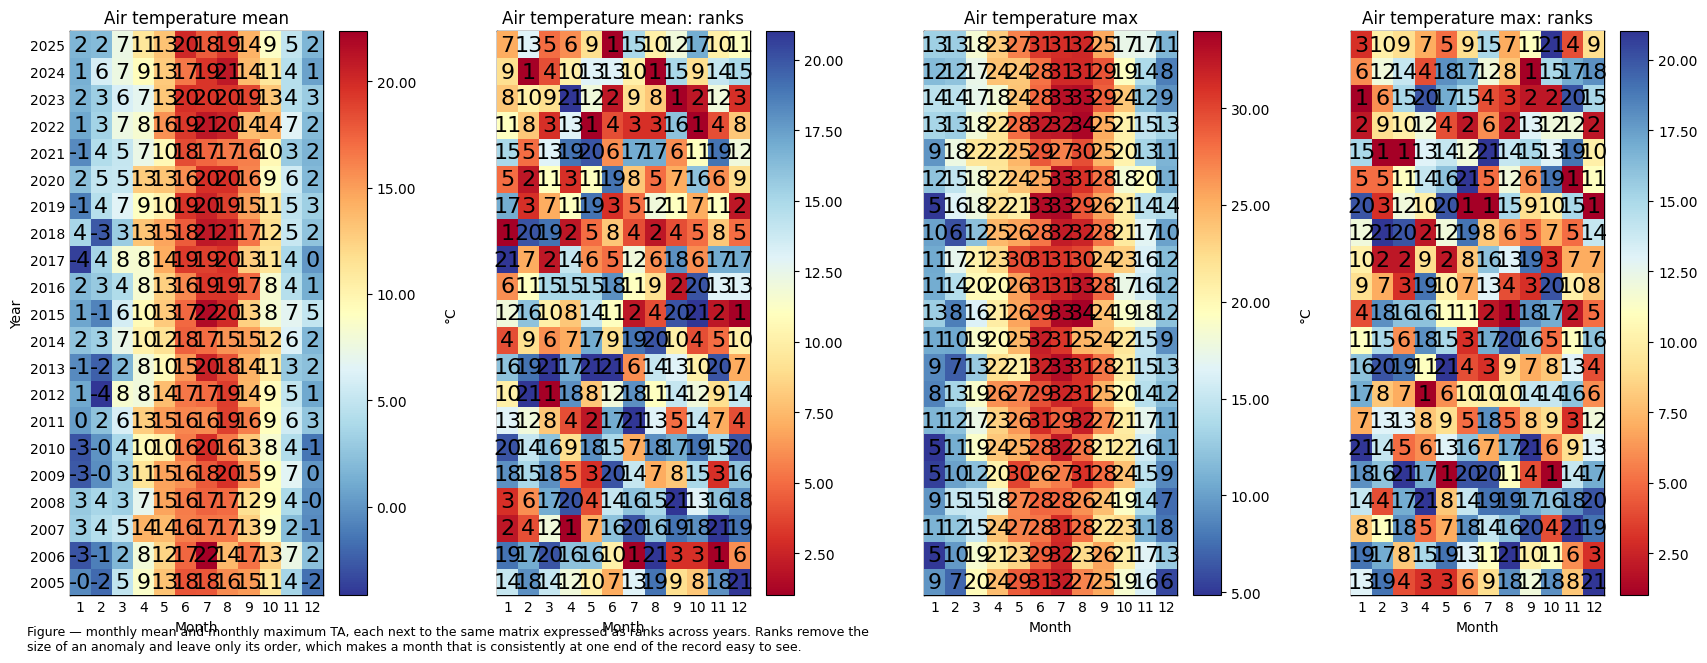

In [37]:
# Figure
fig = plt.figure(facecolor='white', figsize=(17, 6))

# Gridspec for layout
gs = gridspec.GridSpec(1, 4)  # rows, cols
gs.update(wspace=0.35, hspace=0.3, left=0.03, right=0.97, top=0.97, bottom=0.03)
ax_mean = fig.add_subplot(gs[0, 0])
ax_mean_ranks = fig.add_subplot(gs[0, 1])
ax_max = fig.add_subplot(gs[0, 2])
ax_max_ranks = fig.add_subplot(gs[0, 3])
style = dv.plotting.FormatStyle(axlabel_fontsize=10, ticks_fontsize=10)
params = {'show_values': True, 'cb_labelsize': 10, 'format_style': style}

dv.plotting.HeatmapYearMonth(series=series, agg='mean', ranks=False).plot(
    ax=ax_mean, zlabel="°C", cmap="RdYlBu_r", **params)

# Kept as a name: the ranks matrix is read back out of it further down.
hm_mean_ranks = dv.plotting.HeatmapYearMonth(series=series, agg='mean', ranks=True)
hm_mean_ranks.plot(ax=ax_mean_ranks, **params)

dv.plotting.HeatmapYearMonth(series=series, agg='max', ranks=False).plot(
    ax=ax_max, zlabel="°C", cmap="RdYlBu_r", **params)
dv.plotting.HeatmapYearMonth(series=series, agg='max', ranks=True).plot(
    ax=ax_max_ranks, **params)

ax_mean.set_title("Air temperature mean", color='black')
ax_mean_ranks.set_title("Air temperature mean: ranks", color='black')
ax_max.set_title("Air temperature max", color='black')
ax_max_ranks.set_title("Air temperature max: ranks", color='black')

ax_mean.tick_params(left=True, right=False, top=False, bottom=True,
                    labelleft=True, labelright=False, labeltop=False, labelbottom=True)
ax_mean_ranks.tick_params(left=True, right=False, top=False, bottom=True,
                   labelleft=False, labelright=False, labeltop=False, labelbottom=True)
ax_max.tick_params(left=True, right=False, top=False, bottom=True,
                     labelleft=False, labelright=False, labeltop=False, labelbottom=True)
ax_max_ranks.tick_params(left=True, right=False, top=False, bottom=True,
                     labelleft=False, labelright=False, labeltop=False, labelbottom=True)

ax_mean_ranks.set_ylabel("")
figcap(fig, f"monthly mean and monthly maximum {var}, each next to the same matrix expressed as ranks "
            f"across years. Ranks remove the size of an anomaly and leave only its order, which makes "
            f"a month that is consistently at one end of the record easy to see.")
ax_max.set_ylabel("")
ax_max_ranks.set_ylabel("")

fig.show()

### Mean ranks per year

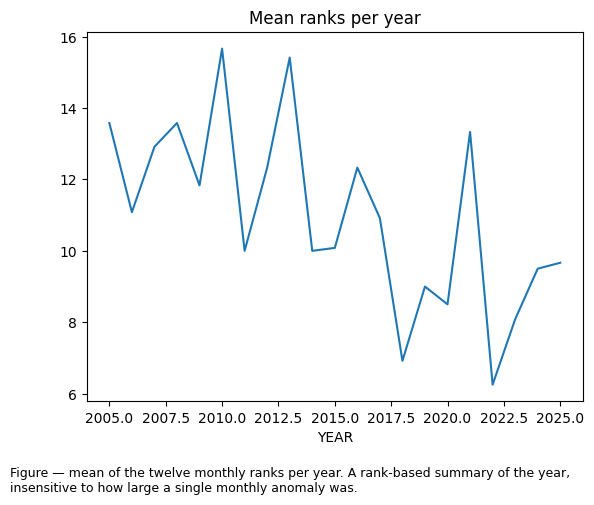

In [38]:
_ax = hm_mean_ranks.get_plot_data().mean(axis=1).plot(title="Mean ranks per year")
figcap(_ax.get_figure(), "mean of the twelve monthly ranks per year. A rank-based summary of the "
                         "year, insensitive to how large a single monthly anomaly was.")

</br>

# Anomalies and trends

## Per year

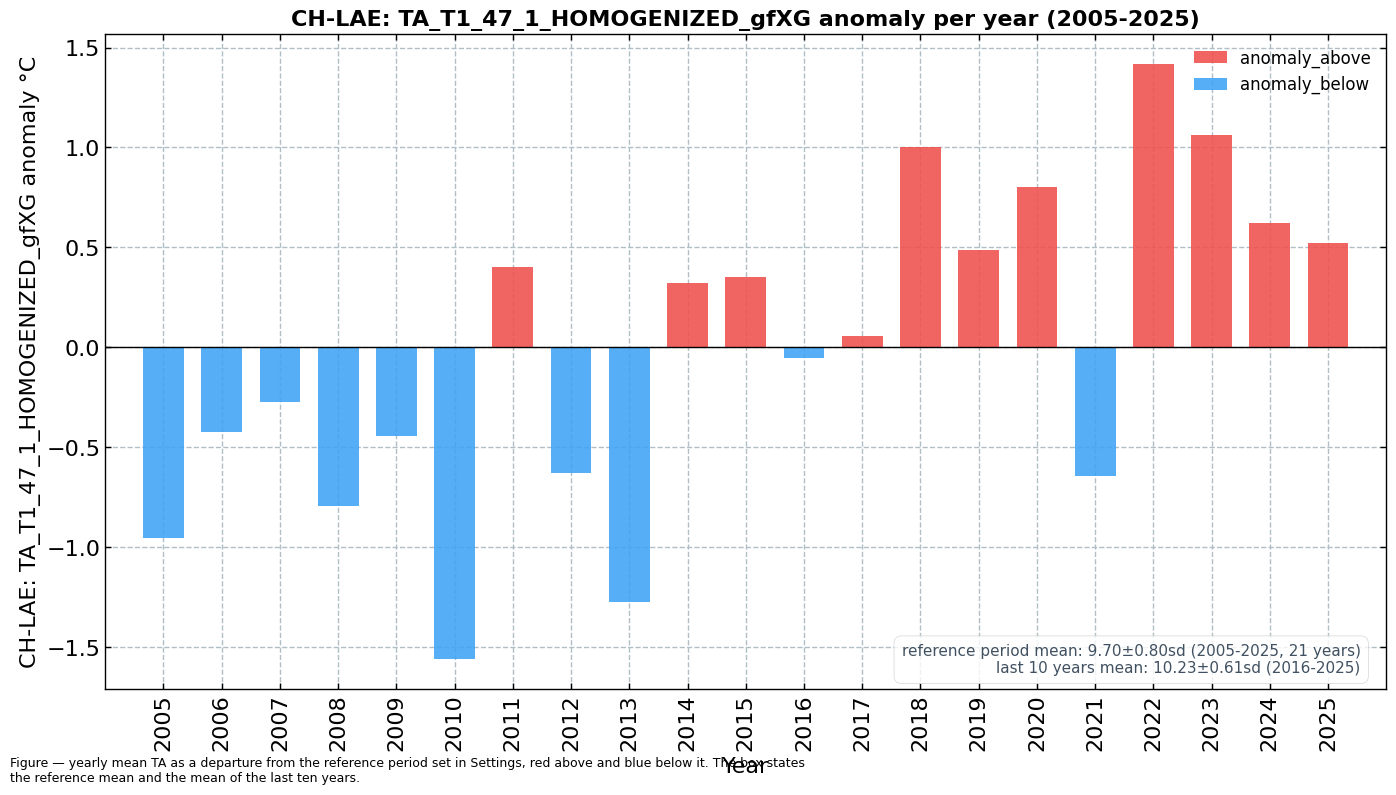

In [39]:
# Reference period from the Settings cell. It spans the whole record here, so the anomalies are
# departures from the record's own mean rather than from a climate normal such as 1991-2020, which
# this dataset is too short to provide.
series_label = f"CH-LAE: {varname}"
_anomalies_year = LongtermAnomaliesYear(series=ym,
                                        series_label=series_label,
                                        series_units=units,
                                        reference_start_year=REFERENCE_START_YEAR,
                                        reference_end_year=REFERENCE_END_YEAR)
_anomalies_year.plot()
figcap(_anomalies_year.fig,
       f"yearly mean {var} as a departure from the reference period set in Settings, red above and "
       f"blue below it. The box states the reference mean and the mean of the last ten years.")

## Per calendar month

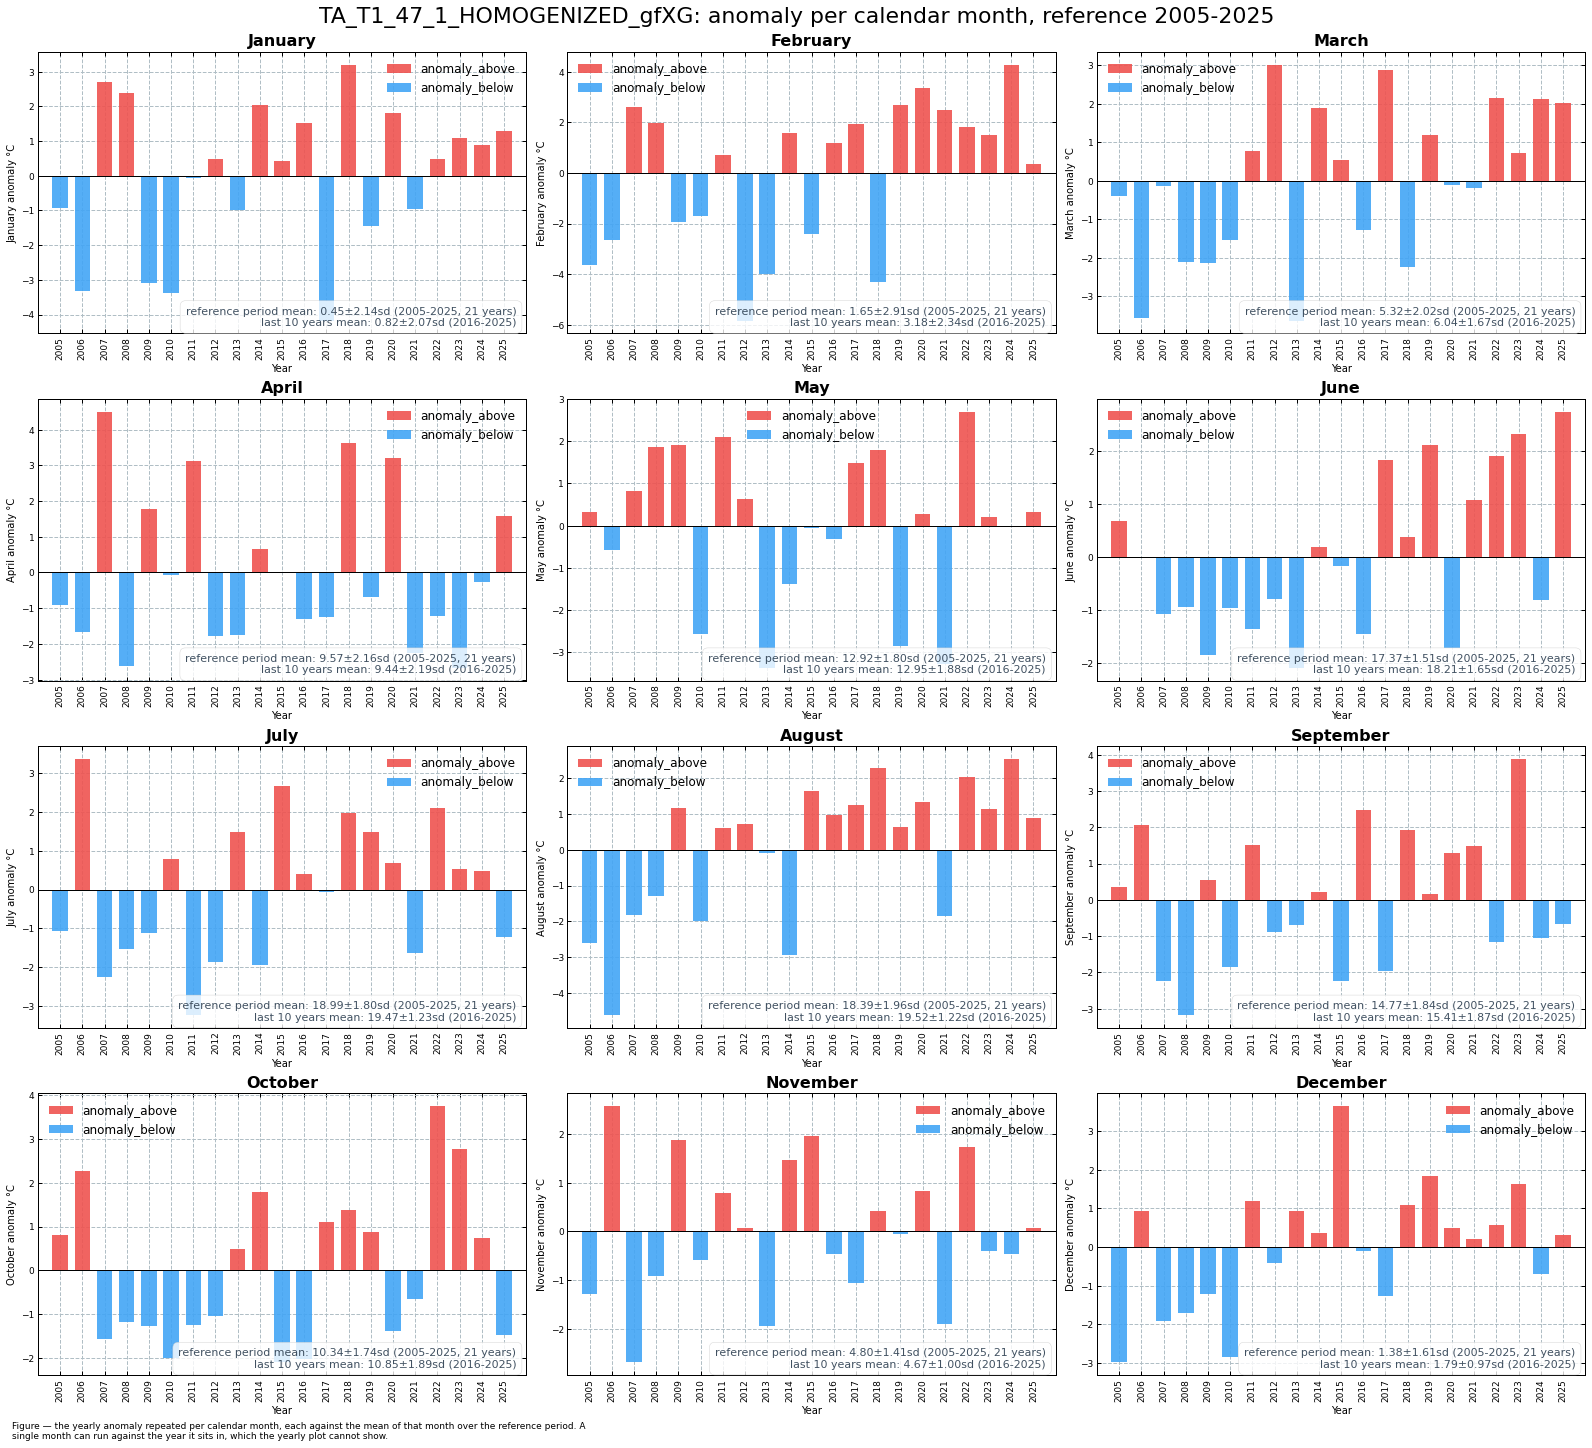

In [40]:
# The same calculation per calendar month, each against the mean of that month over the reference
# period. A single month can run against the year it sits in, which the yearly plot cannot show.
monthly_by_number = per_year_month(series, 'mean', month_names=False)

fig, axs = plt.subplots(nrows=4, ncols=3, figsize=(22, 20), dpi=72, layout="constrained")
fig.suptitle(f"{varname}: anomaly per calendar month, reference "
             f"{REFERENCE_START_YEAR}-{REFERENCE_END_YEAR}", fontsize=22)
for _month, _ax in zip(monthly_by_number.columns, axs.flatten()):
    LongtermAnomaliesYear(series=monthly_by_number[_month].rename(varname),
                          series_label=calendar.month_name[_month],
                          series_units=units,
                          reference_start_year=REFERENCE_START_YEAR,
                          reference_end_year=REFERENCE_END_YEAR).plot(
        ax=_ax, format_style=dv.plotting.FormatStyle(title=calendar.month_name[_month],
                                                     axlabel_fontsize=10, ticks_fontsize=9))
figcap(fig, f"the yearly anomaly repeated per calendar month, each against the mean of that month "
            f"over the reference period. A single month can run against the year it sits in, which "
            f"the yearly plot cannot show.")

## Anomaly by year and month

Table — monthly TA anomaly (°C) against 2005-2025, the numbers behind the grid above



,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
YEAR,,,,,,,,,,,,
2005,-0.9,-3.6,-0.4,-0.9,0.3,0.7,-1.1,-2.6,0.4,0.8,-1.3,-3.0
2006,-3.3,-2.6,-3.6,-1.7,-0.6,-0.0,3.4,-4.6,2.1,2.3,2.6,0.9
2007,2.7,2.6,-0.1,4.5,0.8,-1.1,-2.3,-1.8,-2.2,-1.6,-2.7,-1.9
2008,2.4,2.0,-2.1,-2.6,1.9,-1.0,-1.5,-1.3,-3.2,-1.2,-0.9,-1.7
2009,-3.1,-1.9,-2.1,1.8,1.9,-1.9,-1.1,1.2,0.5,-1.3,1.9,-1.2
2010,-3.4,-1.7,-1.5,-0.1,-2.6,-1.0,0.8,-2.0,-1.8,-2.0,-0.6,-2.8
2011,-0.1,0.7,0.8,3.1,2.1,-1.4,-3.2,0.6,1.5,-1.3,0.8,1.2
2012,0.5,-5.8,3.0,-1.8,0.6,-0.8,-1.9,0.7,-0.9,-1.1,0.1,-0.4
2013,-1.0,-4.0,-3.6,-1.8,-3.4,-2.1,1.5,-0.1,-0.7,0.5,-1.9,0.9


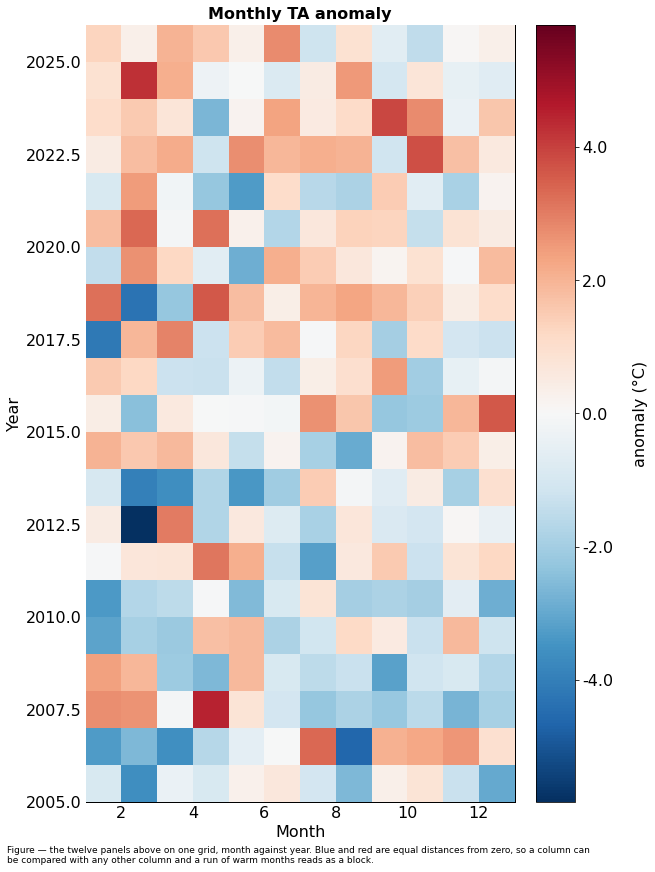

In [41]:
# All twelve panels above on one grid, plus the table behind them. Blue and red are equal distances
# from zero, so a column can be compared with any other column.
anomalies = monthly_avg - monthly_avg.loc[REFERENCE_START_YEAR:REFERENCE_END_YEAR].mean()
_long = monthly_by_number.sub(
    monthly_by_number.loc[REFERENCE_START_YEAR:REFERENCE_END_YEAR].mean()).stack().rename("z").reset_index()
_long.columns = ['YEAR', 'MONTH', 'z']
_absmax = _long['z'].abs().max()

fig, ax = plt.subplots(figsize=(9, 12), dpi=72, layout="constrained")
dv.plotting.HeatmapXYZ(x=_long['MONTH'], y=_long['YEAR'], z=_long['z']).plot(
    ax=ax, cmap='RdBu_r', vmin=-_absmax, vmax=_absmax, cb_digits_after_comma=1,
    xlabel="Month", ylabel="Year", zlabel=f"anomaly ({units})",
    format_style=dv.plotting.FormatStyle(title=f"Monthly {var} anomaly"))
figcap(fig, f"the twelve panels above on one grid, month against year. Blue and red are equal "
            f"distances from zero, so a column can be compared with any other column and a run of "
            f"warm months reads as a block.")

display(styled(anomalies, caption=f"monthly {var} anomaly ({units}) against "
                                  f"{REFERENCE_START_YEAR}-{REFERENCE_END_YEAR}, the numbers "
                                  f"behind the grid above",
               cmap='RdBu_r', axis=None, center=True))

## Stripes

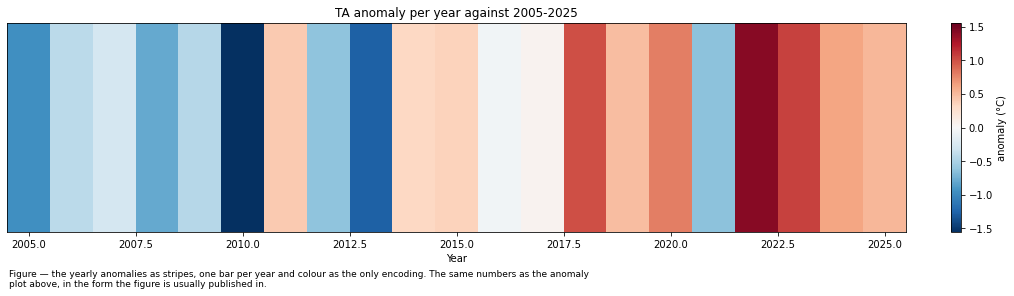

In [42]:
# The yearly anomalies as stripes: the same numbers as the bar plot above, in the form the figure
# is usually published in. One bar per year, no axis, colour is the whole message.
_anomaly = ym - ym.loc[REFERENCE_START_YEAR:REFERENCE_END_YEAR].mean()
_absmax = _anomaly.abs().max()
_cmap = plt.get_cmap('RdBu_r')
_norm = Normalize(vmin=-_absmax, vmax=_absmax)

fig, ax = plt.subplots(figsize=(14, 4), dpi=72, layout="constrained")
ax.bar(_anomaly.index, height=1.0, width=1.0, color=_cmap(_norm(_anomaly.to_numpy())))
ax.set_xlim(_anomaly.index.min() - 0.5, _anomaly.index.max() + 0.5)
ax.set_ylim(0, 1)
ax.set_yticks([])
ax.set_xlabel("Year")
ax.set_title(f"{var} anomaly per year against {REFERENCE_START_YEAR}-{REFERENCE_END_YEAR}")
fig.colorbar(plt.cm.ScalarMappable(norm=_norm, cmap=_cmap), ax=ax, label=f"anomaly ({units})")
figcap(fig, f"the yearly anomalies as stripes, one bar per year and colour as the only encoding. The "
            f"same numbers as the anomaly plot above, in the form the figure is usually published in.")
fig.show()

## Trend of the yearly means

Theil-Sen slope: +0.86 °C per decade (95 % interval +0.44 to +1.37)
Kendall tau:     +0.50 (p = 0.0010)


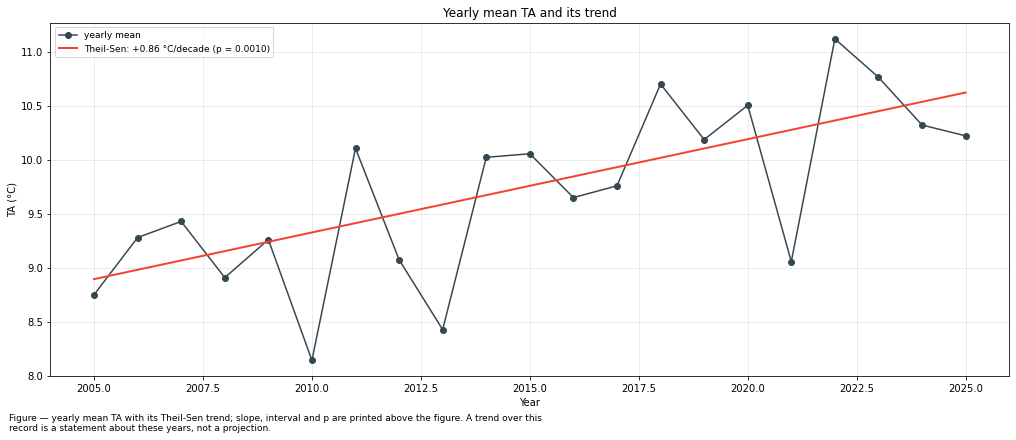

In [43]:
# Trend of the yearly means. Theil-Sen for the slope and Kendall's tau for the significance, see
# the `trend` helper for why. The interval is the 95 % interval of the slope, not of the yearly
# values, and a trend over 21 years is a statement about this record, not a climate projection.
_fit = trend(ym)
print(f"Theil-Sen slope: {_fit['slope']:+.2f} {units} per decade "
      f"(95 % interval {_fit['low']:+.2f} to {_fit['high']:+.2f})")
print(f"Kendall tau:     {_fit['tau']:+.2f} (p = {_fit['pvalue']:.4f})")

fig, ax = plt.subplots(figsize=(14, 6), dpi=72, layout="constrained")
ax.plot(ym.index, ym, marker='o', color='#37474F', lw=1.5, label="yearly mean")
ax.plot(_fit['fit'].index, _fit['fit'], color='#F44336', lw=2,
        label=f"Theil-Sen: {_fit['slope']:+.2f} {units}/decade (p = {_fit['pvalue']:.4f})")
ax.set_xlabel("Year")
ax.set_ylabel(xlabel)
ax.set_title(f"Yearly mean {var} and its trend")
ax.grid(alpha=0.3)
ax.legend(fontsize=9)
figcap(fig, f"yearly mean {var} with its Theil-Sen trend; slope, interval and p are printed above the "
            f"figure. A trend over this record is a statement about these years, not a projection.")
fig.show()

## Trend per calendar month

Table — Theil-Sen trend of monthly mean TA per calendar month with its 95 % interval and Kendall p.
Twelve tests on one record, so a single significant month is weak evidence on its own



,trend (°C/decade),lower 95 % (°C/decade),upper 95 % (°C/decade),p
MONTH,,,,
Jan,0.89,-0.80,2.68,0.3858
Feb,2.44,-0.09,4.24,0.0745
Mar,1.64,0.12,3.03,0.0360
Apr,-0.13,-2.01,1.40,0.9287
May,-0.15,-1.48,1.13,0.8347
Jun,1.36,0.15,2.45,0.0307
Jul,0.69,-0.91,2.20,0.4550
Aug,2.00,0.72,3.12,0.0026
Sep,0.70,-0.79,1.97,0.4921


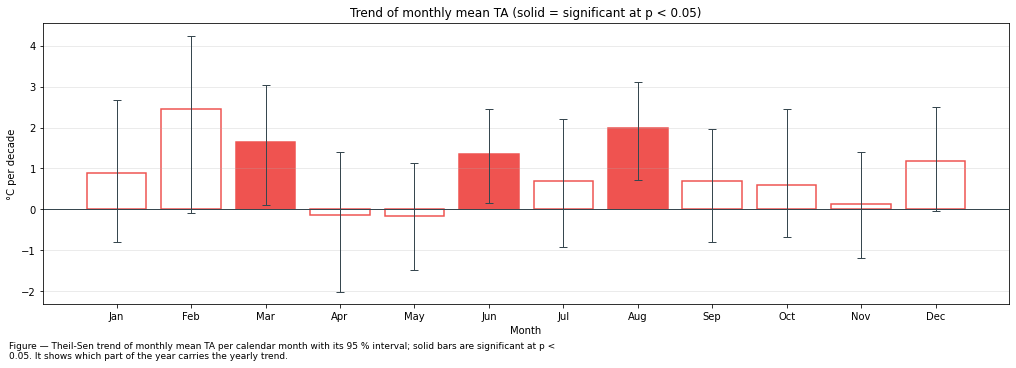

In [44]:
# The same slope fitted to each calendar month separately: which part of the year carries the
# warming. Bars are drawn solid where Kendall's tau is significant at p < 0.05 and hollow where it
# is not; twelve tests on one record means a single significant month is weak evidence on its own.
_rows = {}
for _month in monthly_by_number.columns:
    _fit = trend(monthly_by_number[_month])
    _rows[calendar.month_abbr[_month]] = {
        f"trend ({units}/decade)": _fit['slope'],
        f"lower 95 % ({units}/decade)": _fit['low'],
        f"upper 95 % ({units}/decade)": _fit['high'],
        "p": _fit['pvalue'],
    }
trends = pd.DataFrame.from_dict(_rows, orient='index')
trends.index.name = "MONTH"

_fmt = {c: "{:.2f}" for c in trends.columns}
_fmt["p"] = "{:.4f}"
display(styled(trends, caption=f"Theil-Sen trend of monthly mean {var} per calendar month with its 95 % "
                       f"interval and Kendall p. Twelve tests on one record, so a single "
                       f"significant month is weak evidence on its own", fmt=_fmt,
               subset=[f"trend ({units}/decade)"], cmap='RdBu_r', center=True))

_slope = trends[f"trend ({units}/decade)"]
_significant = trends["p"] < 0.05
fig, ax = plt.subplots(figsize=(14, 5), dpi=72, layout="constrained")
ax.bar(trends.index, _slope, color=['#EF5350' if s else 'white' for s in _significant],
       edgecolor='#EF5350', lw=1.5)
ax.errorbar(trends.index, _slope,
            yerr=[_slope - trends[f"lower 95 % ({units}/decade)"],
                  trends[f"upper 95 % ({units}/decade)"] - _slope],
            fmt='none', ecolor='#37474F', capsize=4, lw=1)
ax.axhline(0, color='#37474F', lw=1)
ax.set_xlabel("Month")
ax.set_ylabel(f"{units} per decade")
ax.set_title(f"Trend of monthly mean {var} (solid = significant at p < 0.05)")
ax.grid(alpha=0.3, axis='y')
figcap(fig, f"Theil-Sen trend of monthly mean {var} per calendar month with its 95 % interval; solid "
            f"bars are significant at p < 0.05. It shows which part of the year carries the yearly "
            f"trend.")
fig.show()

</br>

# Cumulative plot

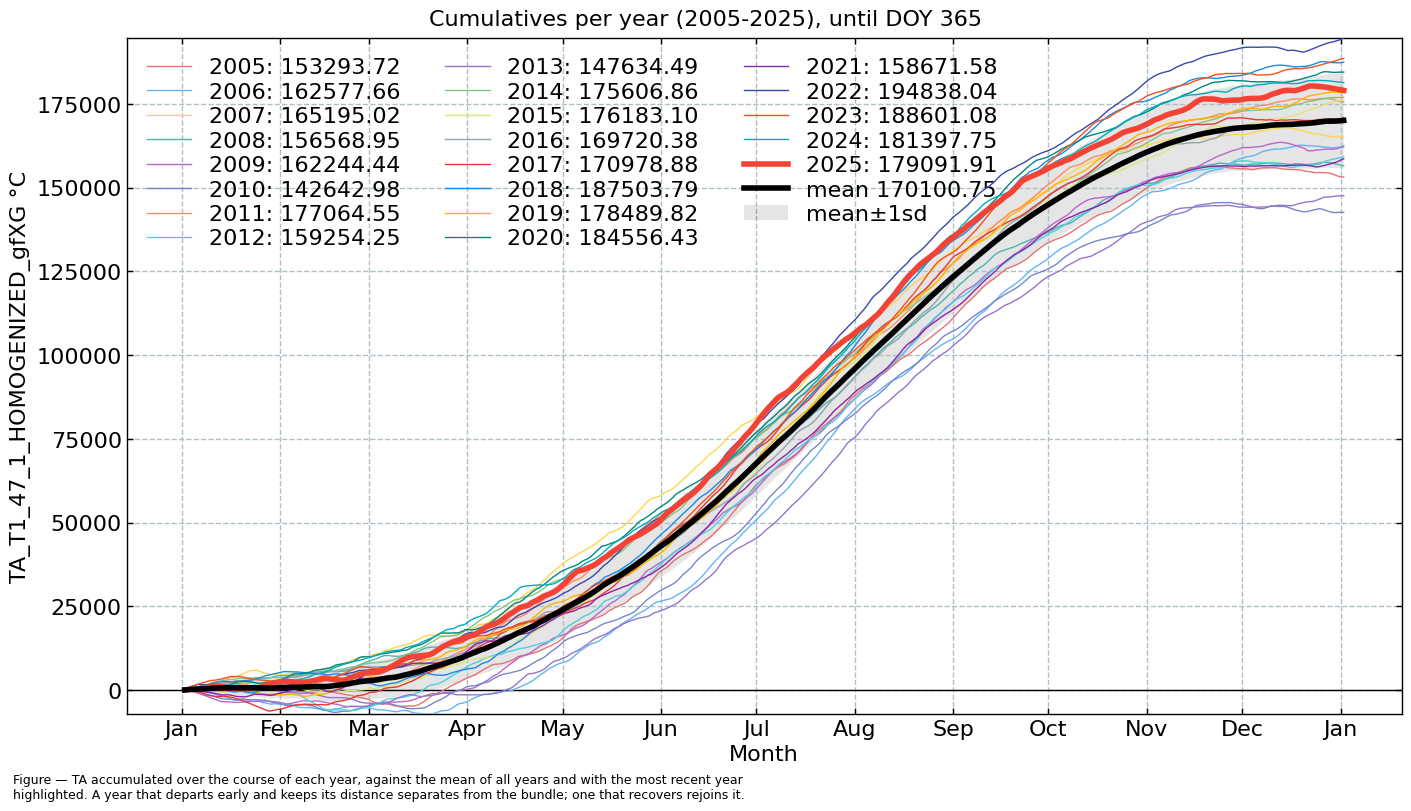

In [45]:
_cumulative = CumulativeYear(
    series=series,
    series_units=units,
    start_year=FIRST_YEAR,
    end_year=LAST_YEAR,
    show_reference=True,
    excl_years_from_reference=None,
    highlight_year=LAST_YEAR)
_cumulative.plot(highlight_year_color='#F44336')
figcap(_cumulative.fig,
       f"{var} accumulated over the course of each year, against the mean of all years and with the "
       f"most recent year highlighted. A year that departs early and keeps its distance separates "
       f"from the bundle; one that recovers rejoins it.")

</br>

# Comparison with the MeteoSwiss reference station

This is the comparison that found the 2016 sensor change, and it now serves as the check that the
homogenisation removed it. The MeteoSwiss station Lägern is 2.5 km from the tower at 845 m a.s.l.
and is operated by a different institution, so the difference against it removes the weather and
leaves the instruments. The elevation difference means a constant offset is expected; what matters
is whether that offset stays constant.

Both columns are compared below. The measured column should show a step of about +1.3 °C at
21 January 2016; the homogenised column should not. A residual seasonal wobble is expected in both,
because the elevation difference does not act equally in all seasons, and so is a residual daytime
difference, because the two tower sensors were shielded differently.


In [46]:
# The reference product is written by 10_METEO/10_REFERENCE and is stored on TIMESTAMP_END, so it
# is shifted onto the product's TIMESTAMP_MIDDLE before anything is compared.
REFDIR = r"F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data\workflow\10_METEO\10_REFERENCE"
REFFILE = "MeteoSwiss_LAE_30MIN_2004-2025.parquet"
_reference = pd.read_parquet(Path(REFDIR) / REFFILE)['TA_LAE_MS']
_reference.index = _reference.index - pd.Timedelta('15min')

# Measured records only, from both columns, so the step and its removal are visible side by side.
_meas = df[flagname] == 0
both = pd.concat([df.loc[_meas, varname_measured].rename('measured'),
                  df.loc[_meas, varname].rename('homogenised'),
                  _reference.rename('reference')], axis=1, sort=True).dropna()
assert len(both) > 100_000, f"only {len(both)} overlapping half-hours with the reference station"

residual = (both['homogenised'] - both['reference']).rename('residual')
print(f"Overlap:  {len(both):,} measured half-hours, "
      f"{both.index[0]:%Y-%m-%d} to {both.index[-1]:%Y-%m-%d}")
for _name in ('measured', 'homogenised'):
    _r = both[_name] - both['reference']
    print(f"Residual ({_name:12s}): {_r.mean():+.2f} {units} +/- {_r.std():.2f} {units} SD")
print(f"Correlation: r = {both['homogenised'].corr(both['reference']):.4f}")

# The step across the sensor change, before and after homogenisation. Complete years either side,
# so the January 2016 outage does not sit inside a compared window.
_break_year = int(df.index[df[sourcename] == 0][0].year)
for _name in ('measured', 'homogenised'):
    _r = both[_name] - both['reference']
    _before = _r[(_r.index.year >= _break_year - 3) & (_r.index.year <= _break_year - 1)].mean()
    _after = _r[(_r.index.year >= _break_year + 1) & (_r.index.year <= _break_year + 3)].mean()
    print(f"Step at the sensor change ({_name:12s}): {_after - _before:+.2f} {units}")


Overlap:  363,913 measured half-hours, 2005-01-01 to 2025-12-31
Residual (measured    ): +0.67 °C +/- 1.20 °C SD
Residual (homogenised ): +1.37 °C +/- 0.94 °C SD
Correlation: r = 0.9934
Step at the sensor change (measured    ): +1.51 °C
Step at the sensor change (homogenised ): +0.19 °C


## Residual over time

Table — residual against the MeteoSwiss station per year. A stable mean residual is what supports
the tower record; a step in one year would point at a change at one of the two stations rather than
at the weather



,mean residual (°C),SD (°C),overlapping half-hours
YEAR,,,
2005,1.27,0.82,17486
2006,1.11,1.00,17494
2007,1.16,0.97,17507
2008,1.22,0.81,17548
2009,1.21,0.88,17036
2010,1.35,0.66,17351
2011,1.37,0.91,17499
2012,1.40,0.78,16286
2013,1.35,0.89,17434


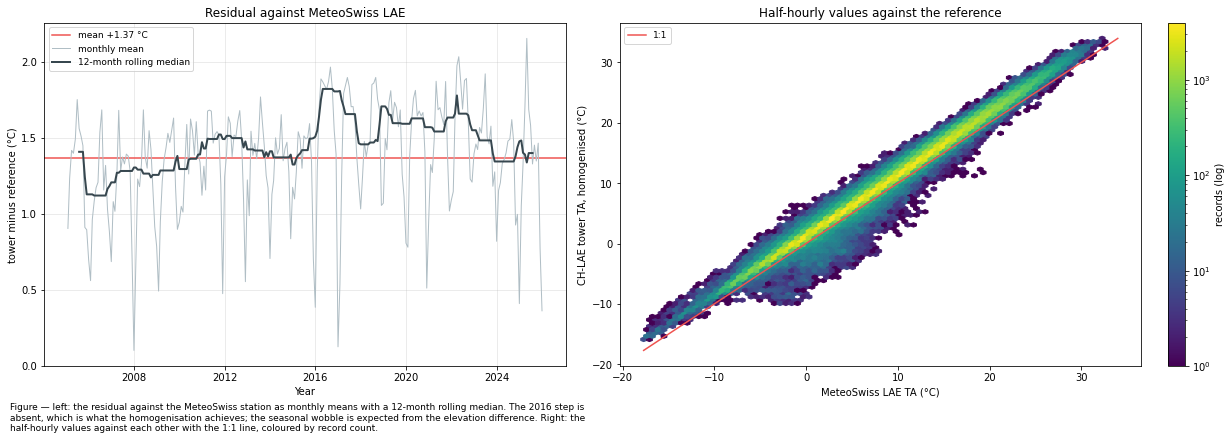

In [47]:
# Left: the residual as monthly means with a 12-month rolling median through it. A drift or a step
# there is what would disqualify the tower record; a seasonal wobble is expected, because the
# elevation difference does not act equally in all seasons.
# Right: the two series against each other, with the 1:1 line for orientation.
_monthly_residual = residual.resample('ME').mean()

fig, axs = plt.subplots(ncols=2, figsize=(17, 6), dpi=72, layout="constrained")
axs[0].axhline(residual.mean(), color='#EF5350', lw=1.5,
               label=f"mean {residual.mean():+.2f} {units}")
axs[0].plot(_monthly_residual.index, _monthly_residual, color='#B0BEC5', lw=1, label="monthly mean")
axs[0].plot(_monthly_residual.index, _monthly_residual.rolling(12, center=True).median(),
            color='#37474F', lw=2, label="12-month rolling median")
axs[0].set_xlabel("Year")
axs[0].set_ylabel(f"tower minus reference ({units})")
axs[0].set_title("Residual against MeteoSwiss LAE")
axs[0].grid(alpha=0.3)
axs[0].legend(fontsize=9)

_hb = axs[1].hexbin(both['reference'], both['homogenised'], gridsize=80, bins='log', cmap='viridis')
_line = [both.min().min(), both.max().max()]
axs[1].plot(_line, _line, color='#EF5350', lw=1.5, label="1:1")
axs[1].set_xlabel(f"MeteoSwiss LAE {var} ({units})")
axs[1].set_ylabel(f"CH-LAE tower {var}, homogenised ({units})")
axs[1].set_title("Half-hourly values against the reference")
axs[1].legend(fontsize=9)
fig.colorbar(_hb, ax=axs[1], label="records (log)")
figcap(fig, f"left: the residual against the MeteoSwiss station as monthly means with a 12-month "
            f"rolling median. The 2016 step is absent, which is what the homogenisation achieves; the "
            f"seasonal wobble is expected from the elevation difference. Right: the half-hourly "
            f"values against each other with the 1:1 line, coloured by record count.")

_yearly_residual = pd.DataFrame({
    f"mean residual ({units})": per_year(residual, 'mean'),
    f"SD ({units})": per_year(residual, 'std'),
    "overlapping half-hours": per_year(residual, 'count'),
})
_fmt = {c: "{:.2f}" for c in _yearly_residual.columns}
_fmt["overlapping half-hours"] = "{:.0f}"
display(styled(_yearly_residual, caption="residual against the MeteoSwiss station per year. A stable mean residual is what supports the tower record; a step in one year would point at a change at one of the two stations rather than at the weather", fmt=_fmt,
               subset=[f"mean residual ({units})"], cmap='RdBu_r', center=True))

</br>

# Appendix: single-year detail

Two figures per year, drawn only when `SHOW_PER_YEAR_DETAIL` is set in the Settings cell. They repeat the distributions above year by year and are kept at the end because they are detail, not overview.

## Single years per month

F:\dev\diive\diive\core\plotting\ridgeline.py:153: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  self.fig = plt.figure(figsize=(self.fig_width, self.fig_height),


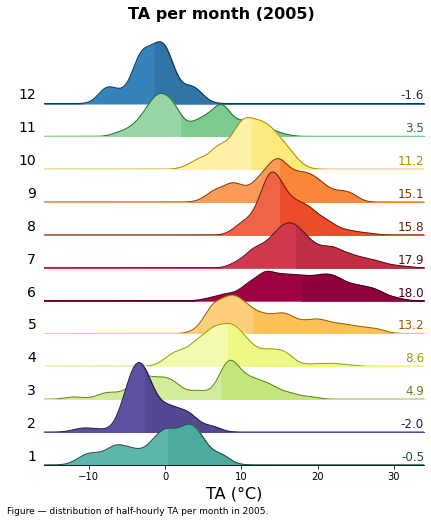

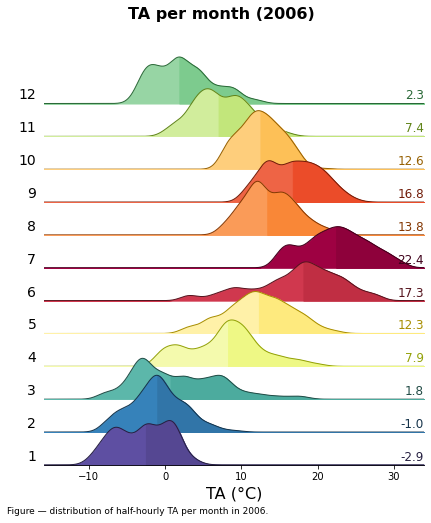

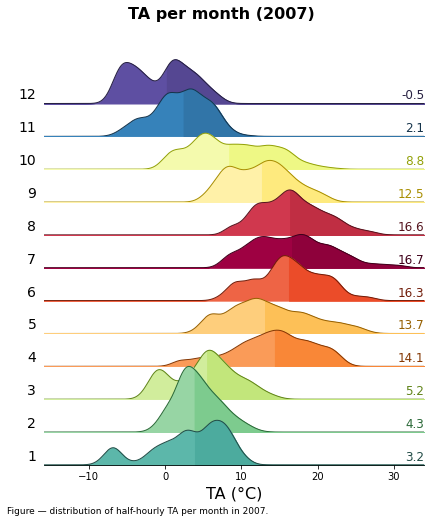

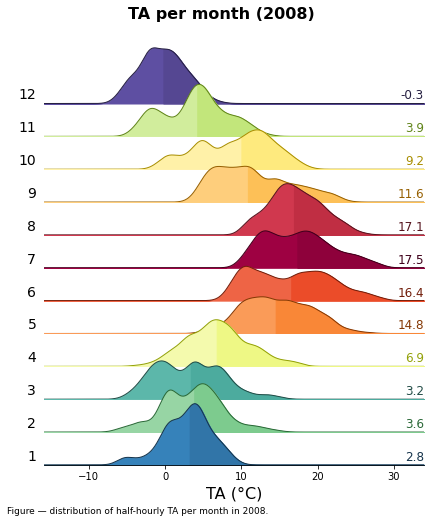

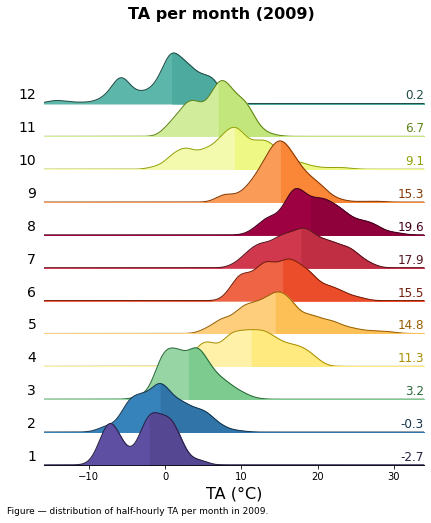

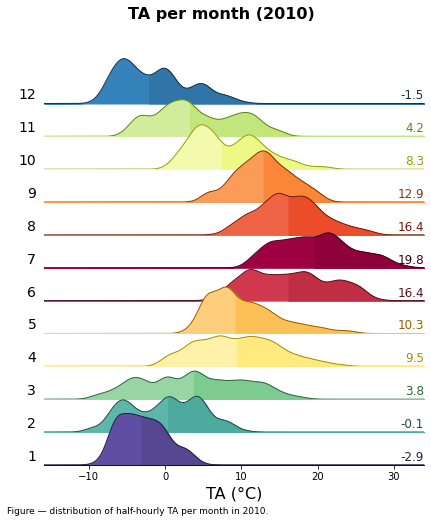

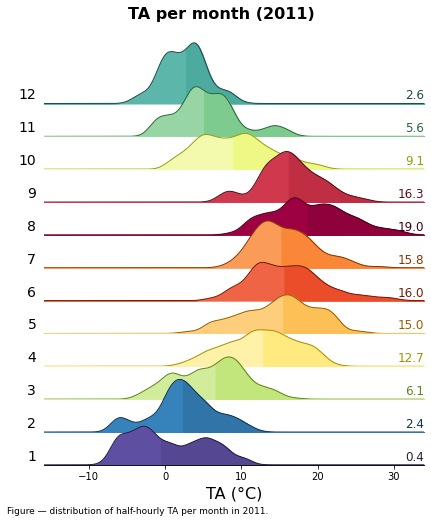

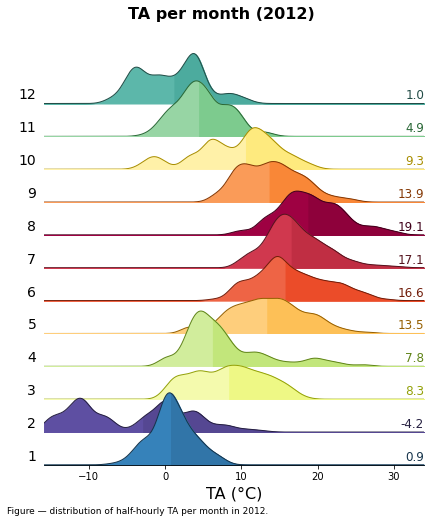

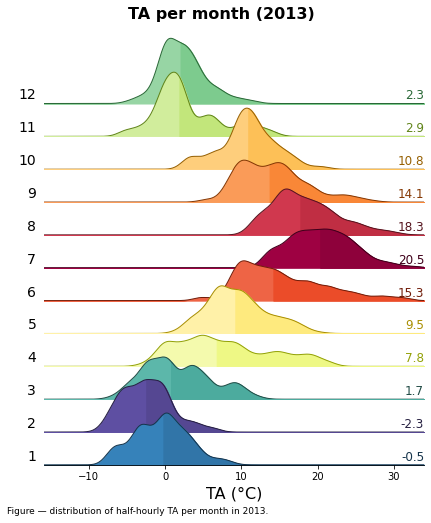

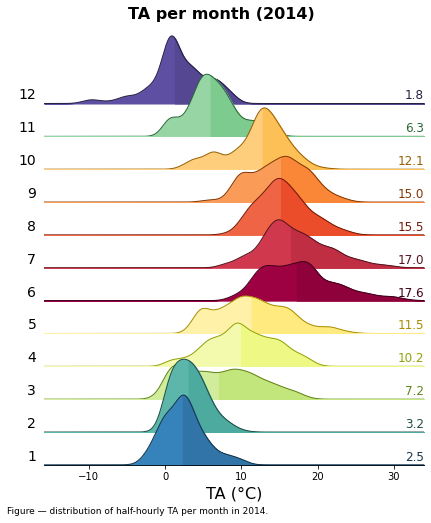

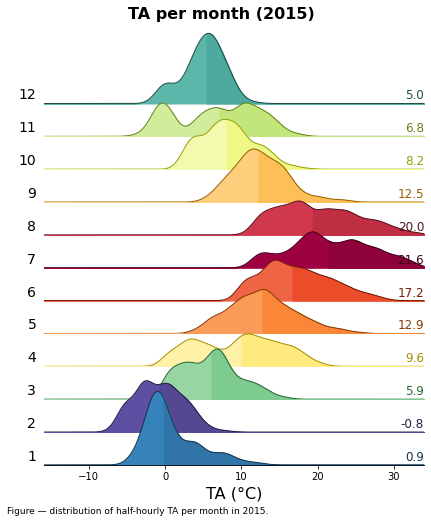

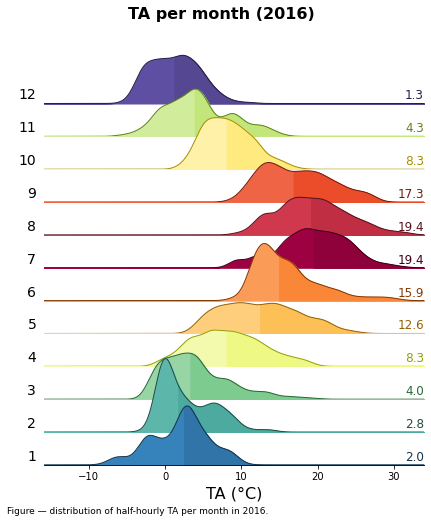

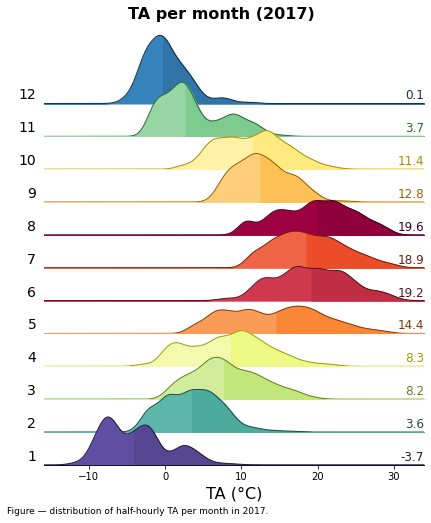

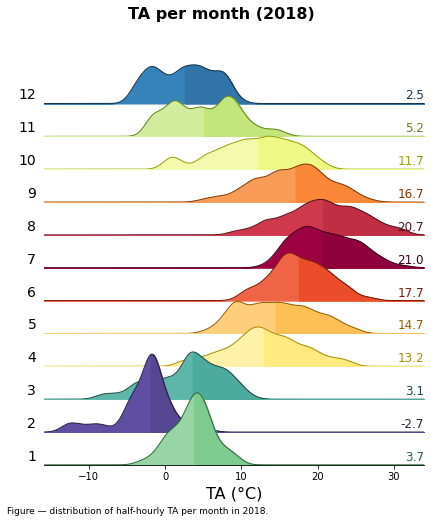

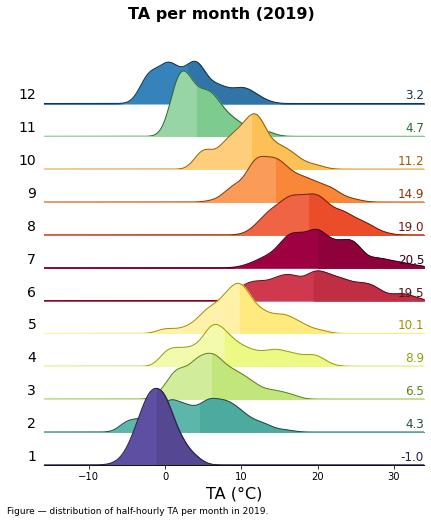

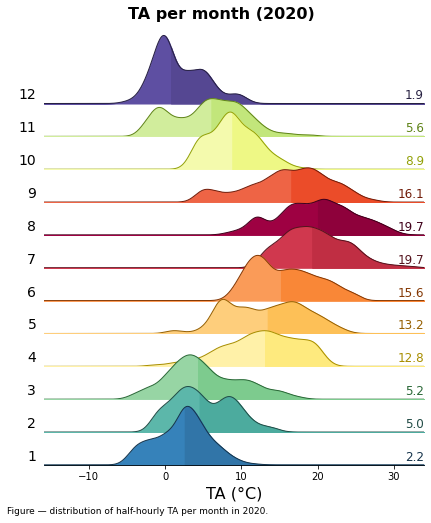

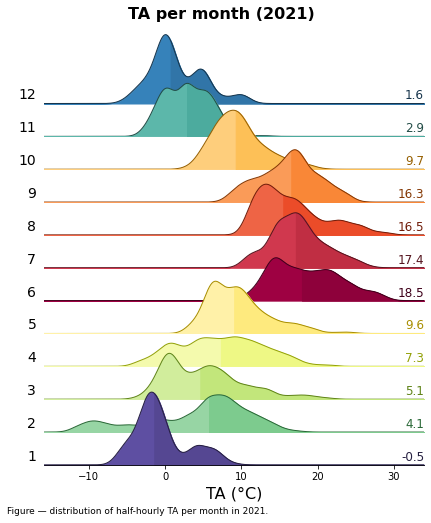

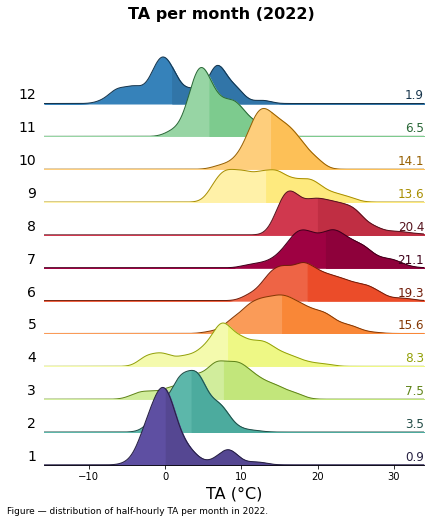

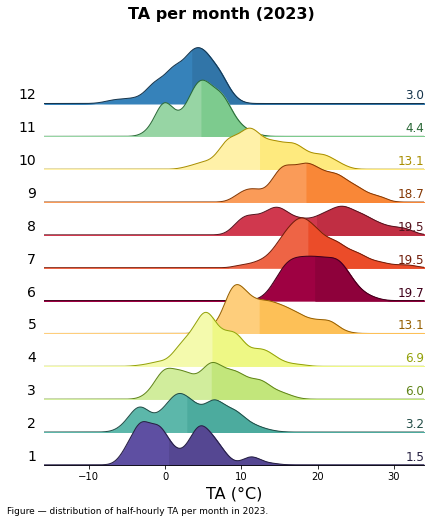

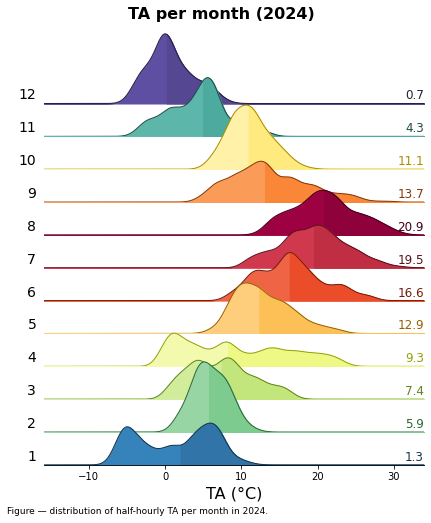

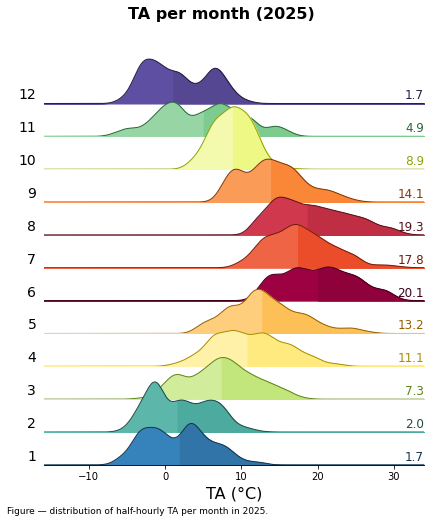

In [48]:
if SHOW_PER_YEAR_DETAIL:
    uniq_years = series.index.year.unique()
    for uy in uniq_years:
        series_yr = series.loc[series.index.year == uy].copy()
        rp = dv.plotting.RidgeLinePlot(series=series_yr)
        rp.plot(
            how='monthly',
            kd_kwargs=None,  # params from scikit KernelDensity as dict
            xlim=xlim,  # min/max as list
            ylim=[0, 0.18],  # min/max as list
            hspace=-0.6,  # overlap
            fig_width=6,
            fig_height=7,
            shade_percentile=0.5,
            show_mean_line=False,
            format_style=dv.plotting.FormatStyle(xlabel=xlabel, title=f"{var} per month ({uy})"),
            fig_dpi=72,
            showplot=True,
            ascending=False
        )
        figcap(rp.fig, f"distribution of half-hourly {var} per month in {uy}.")

## Single years per week

F:\dev\diive\diive\core\plotting\ridgeline.py:153: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  self.fig = plt.figure(figsize=(self.fig_width, self.fig_height),


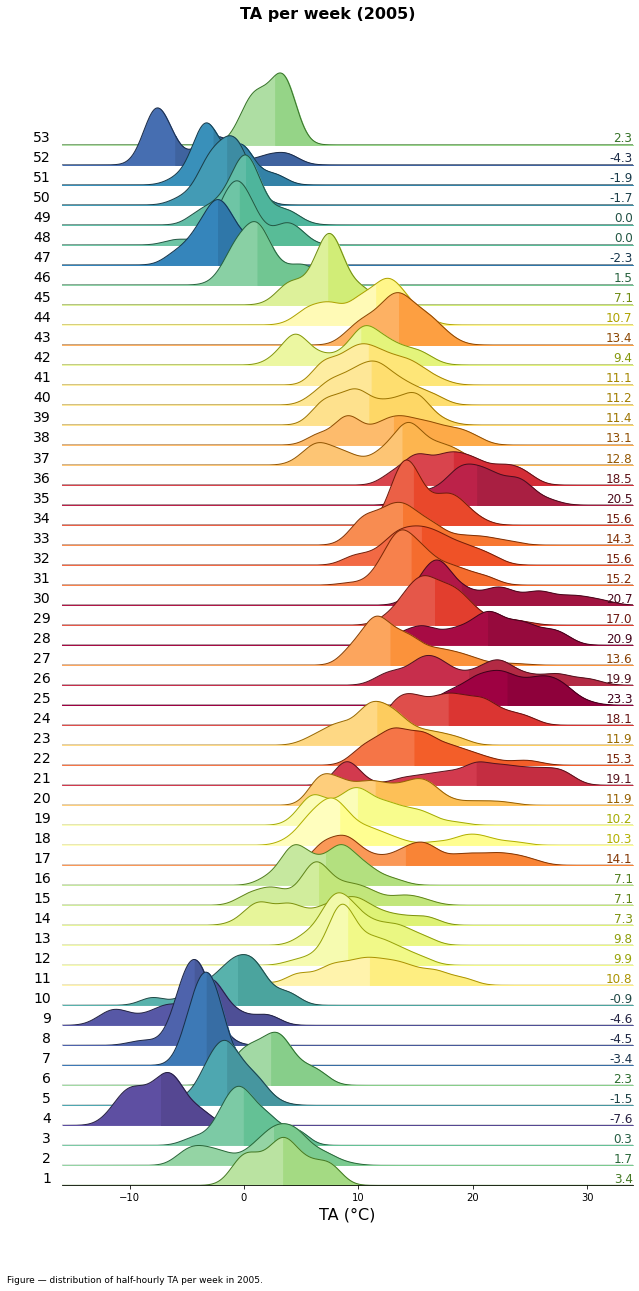

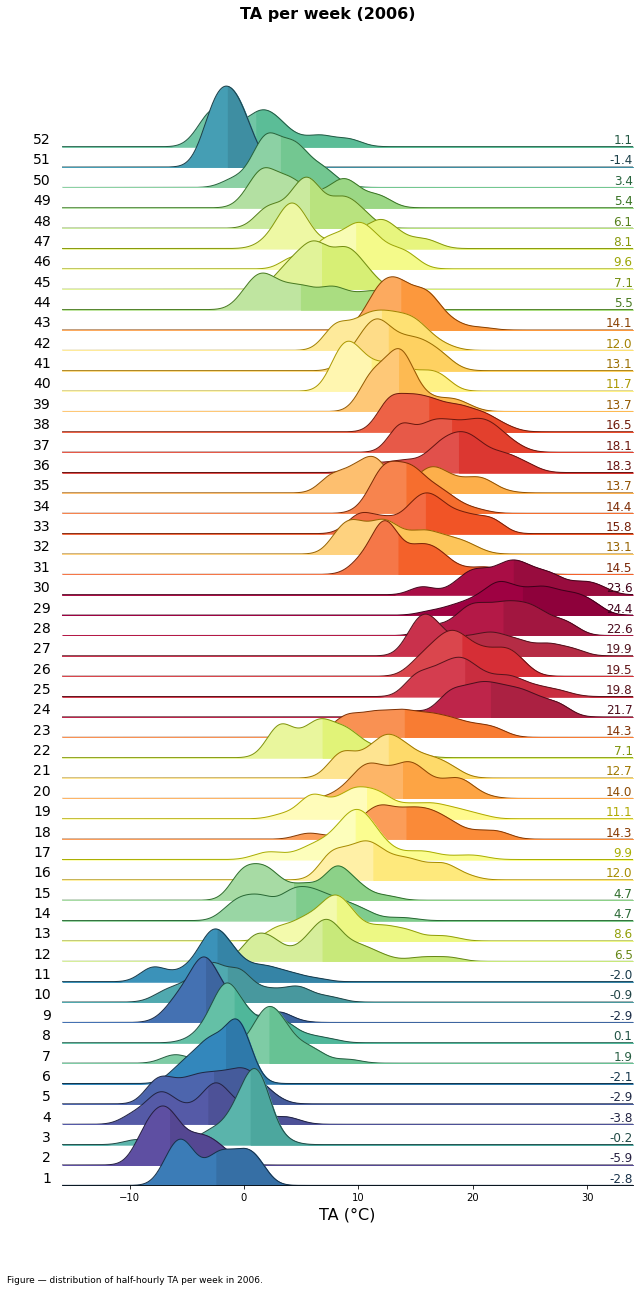

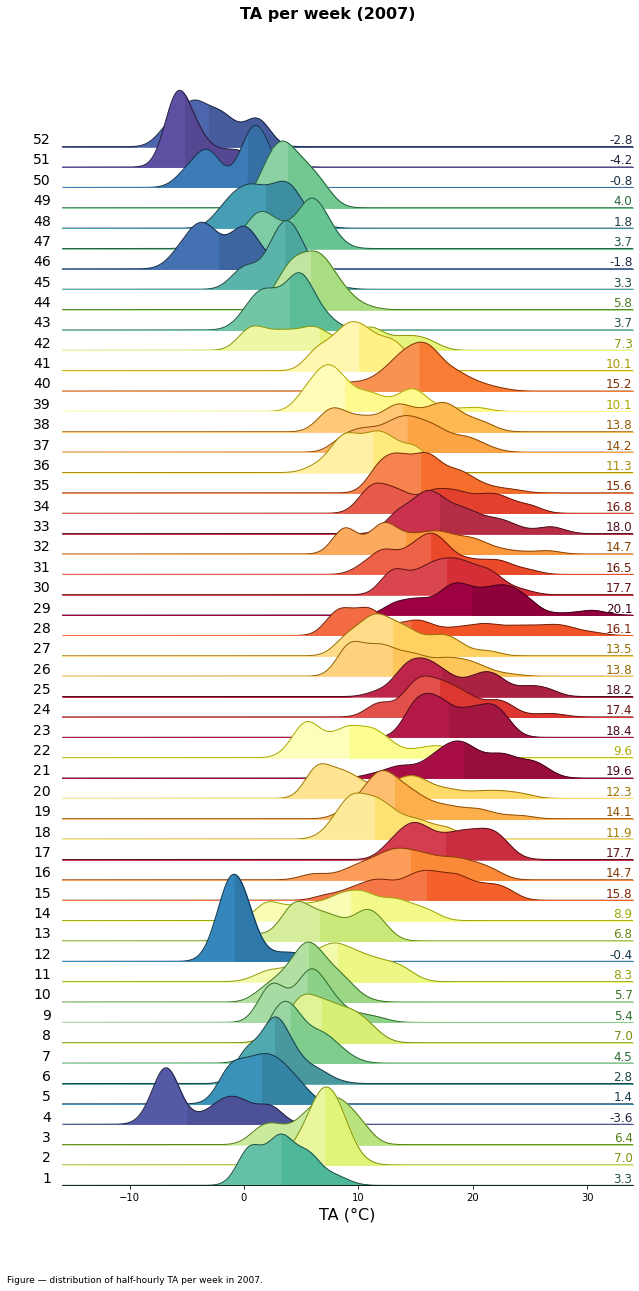

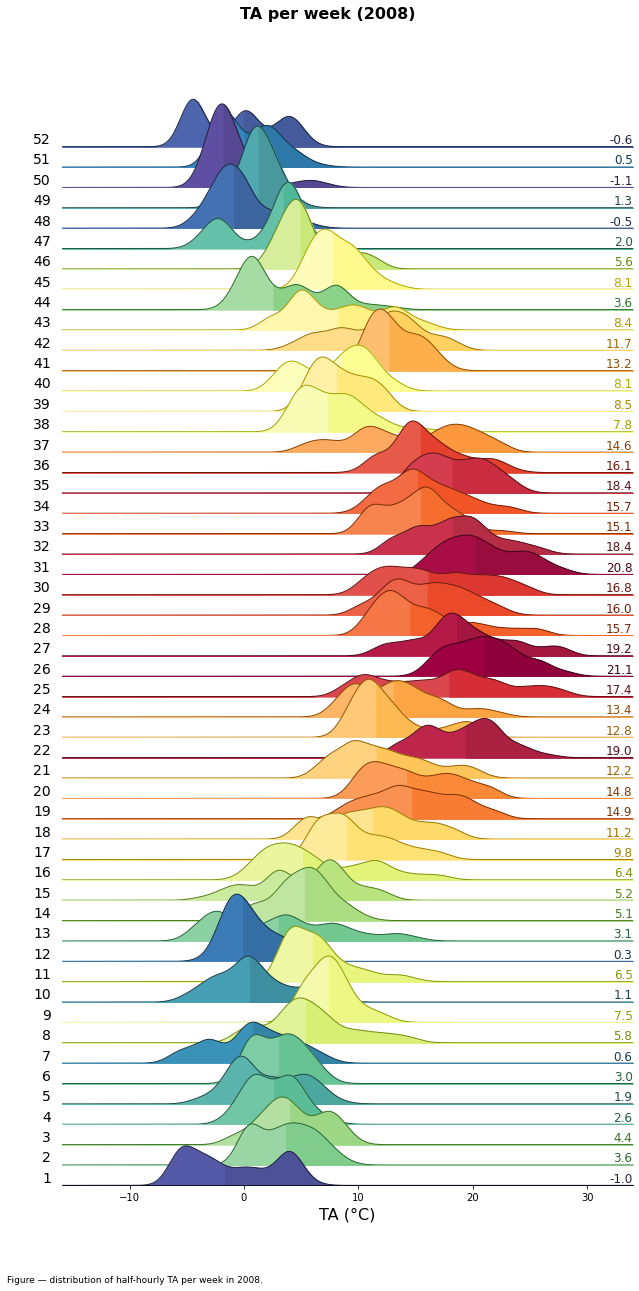

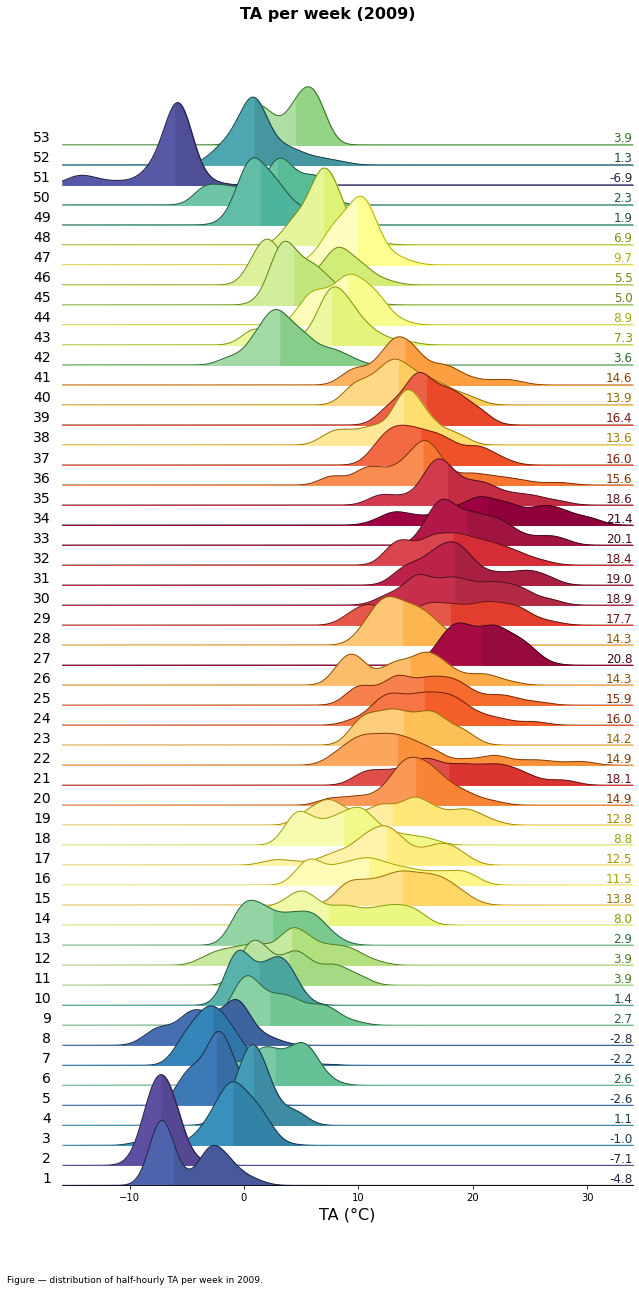

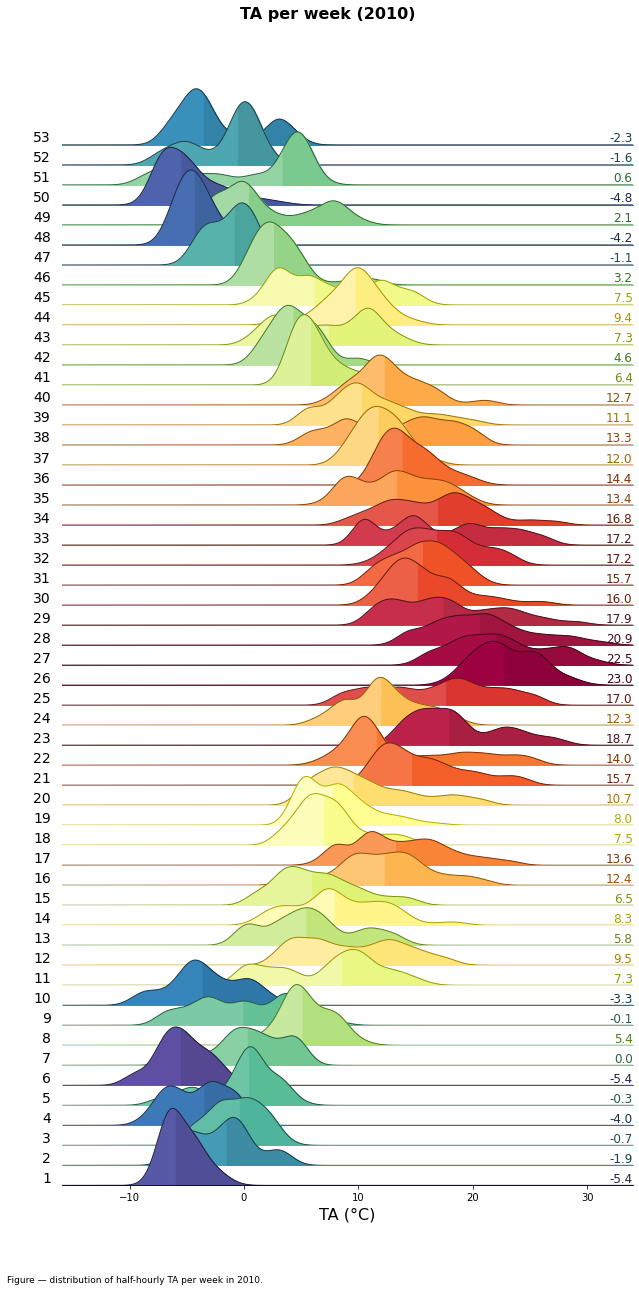

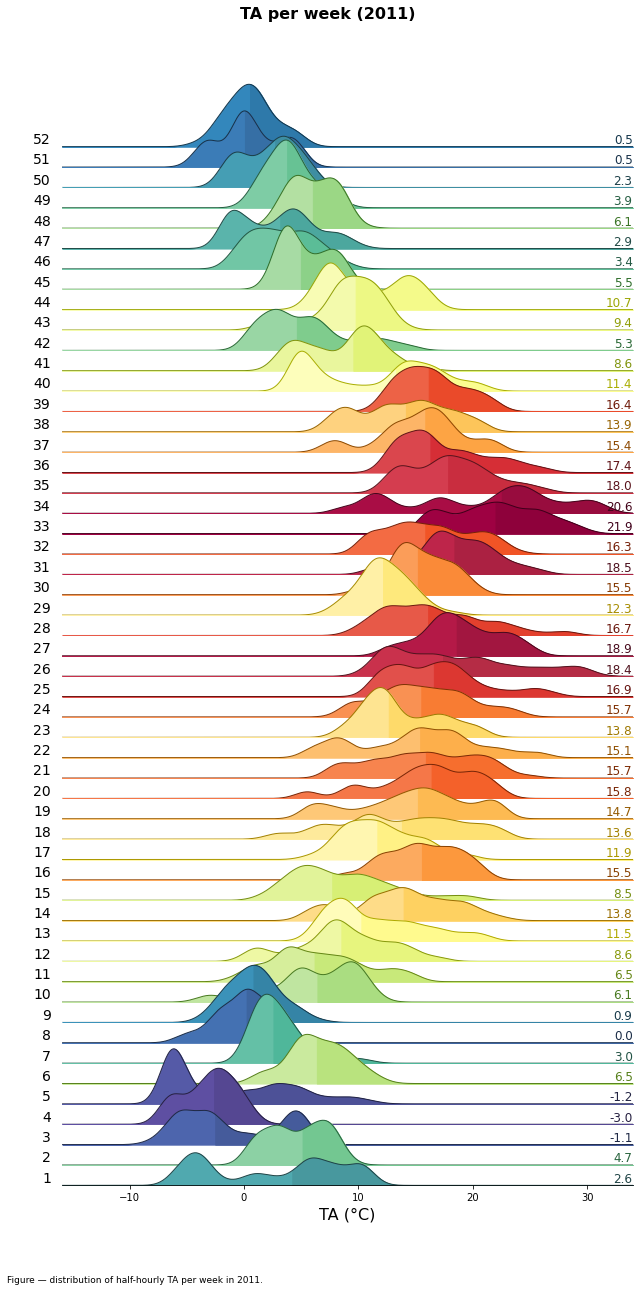

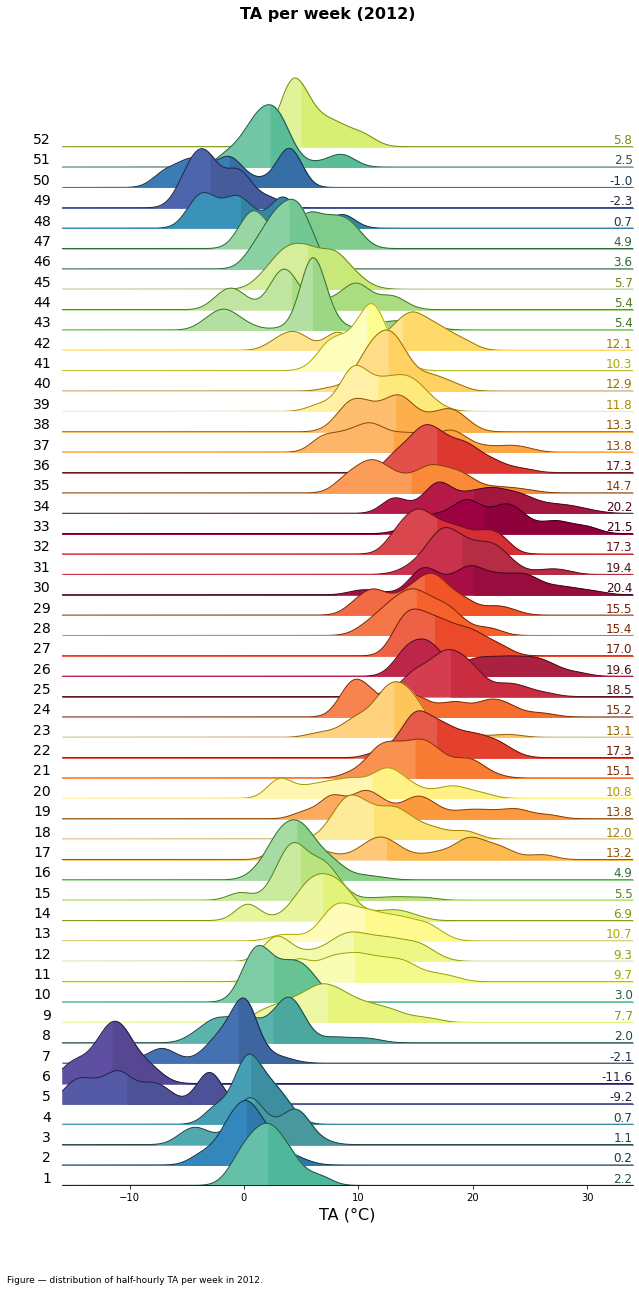

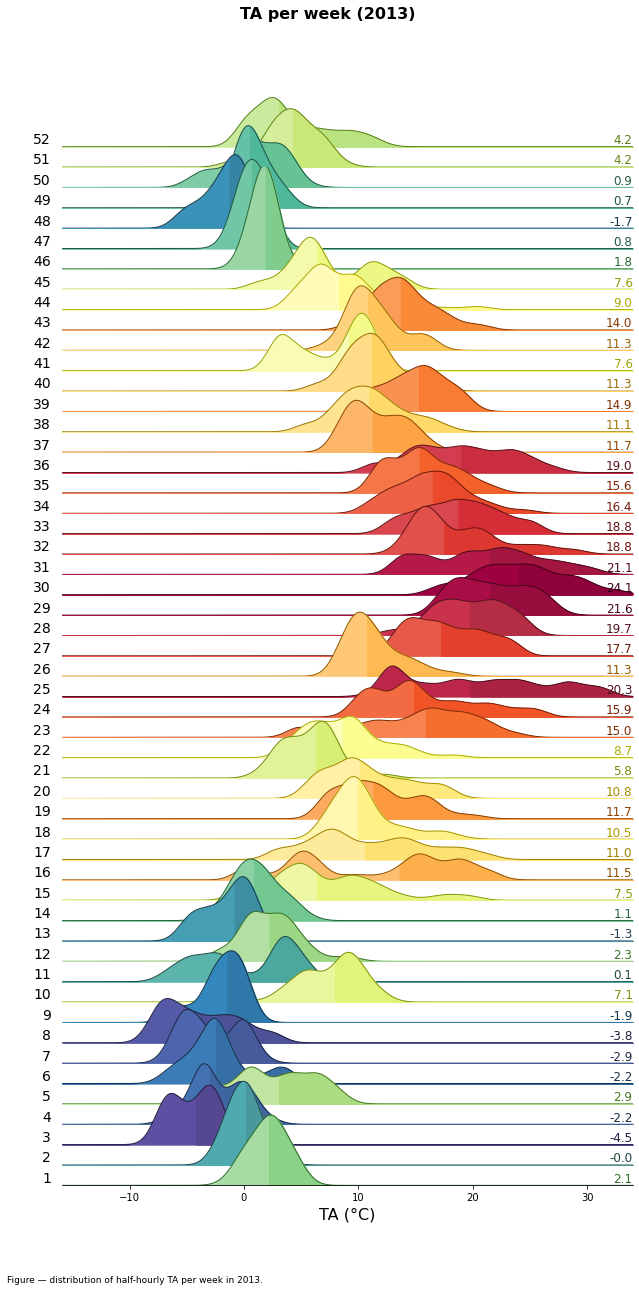

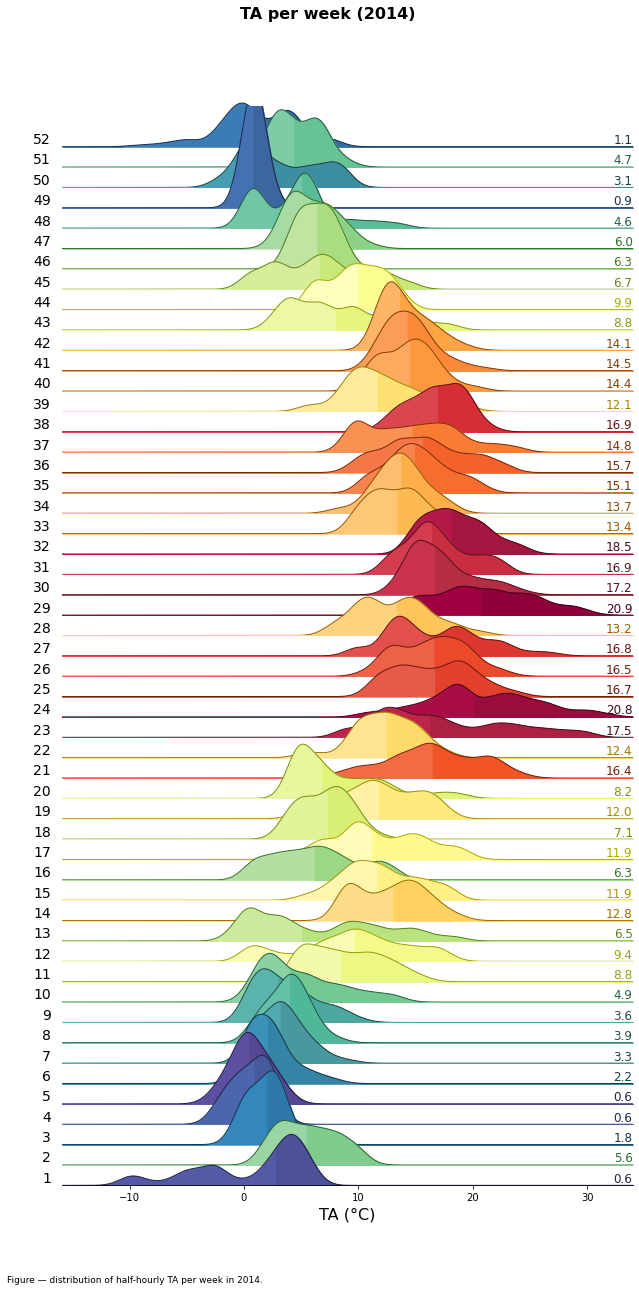

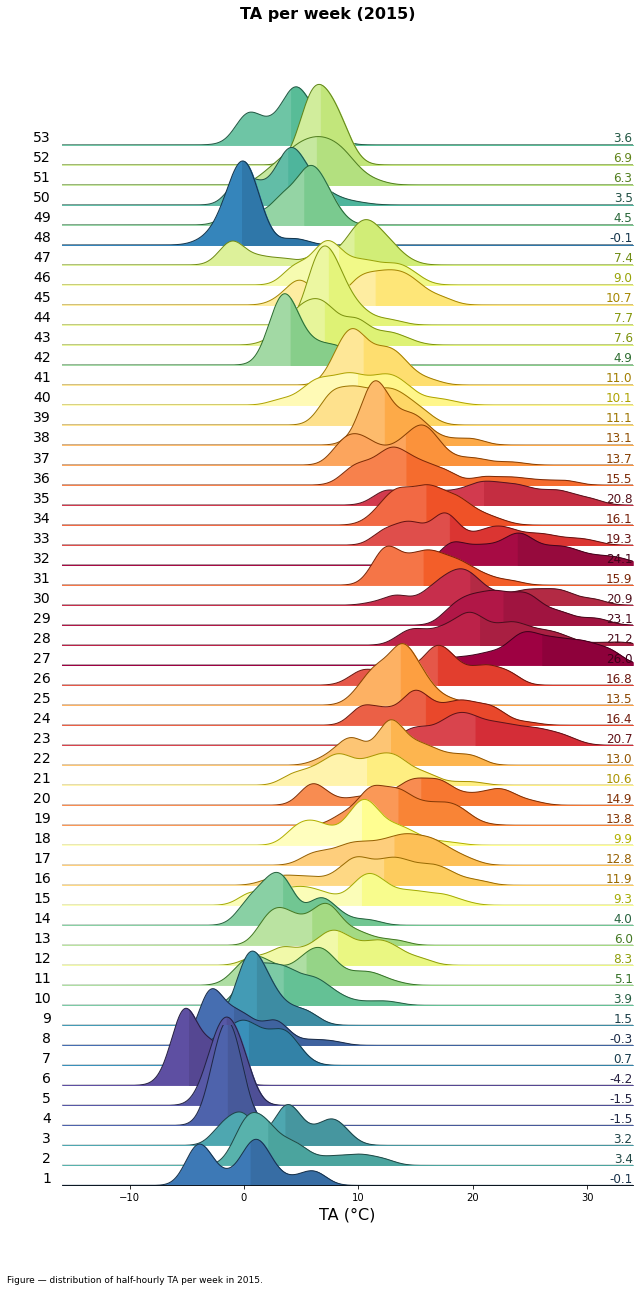

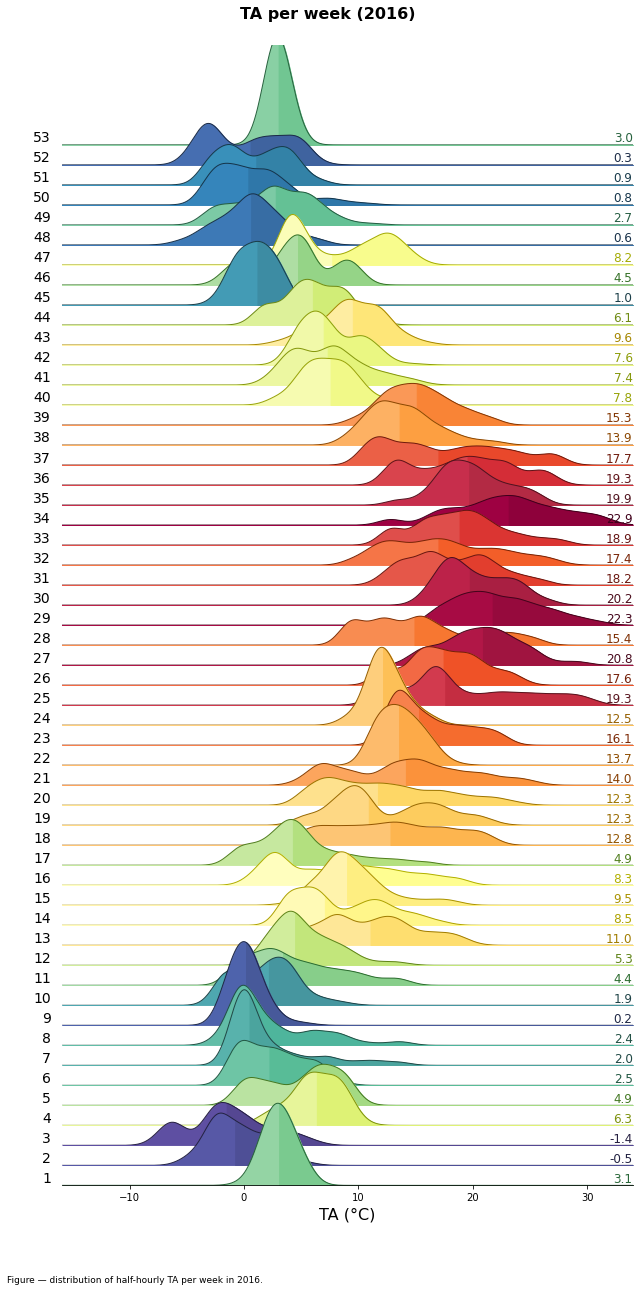

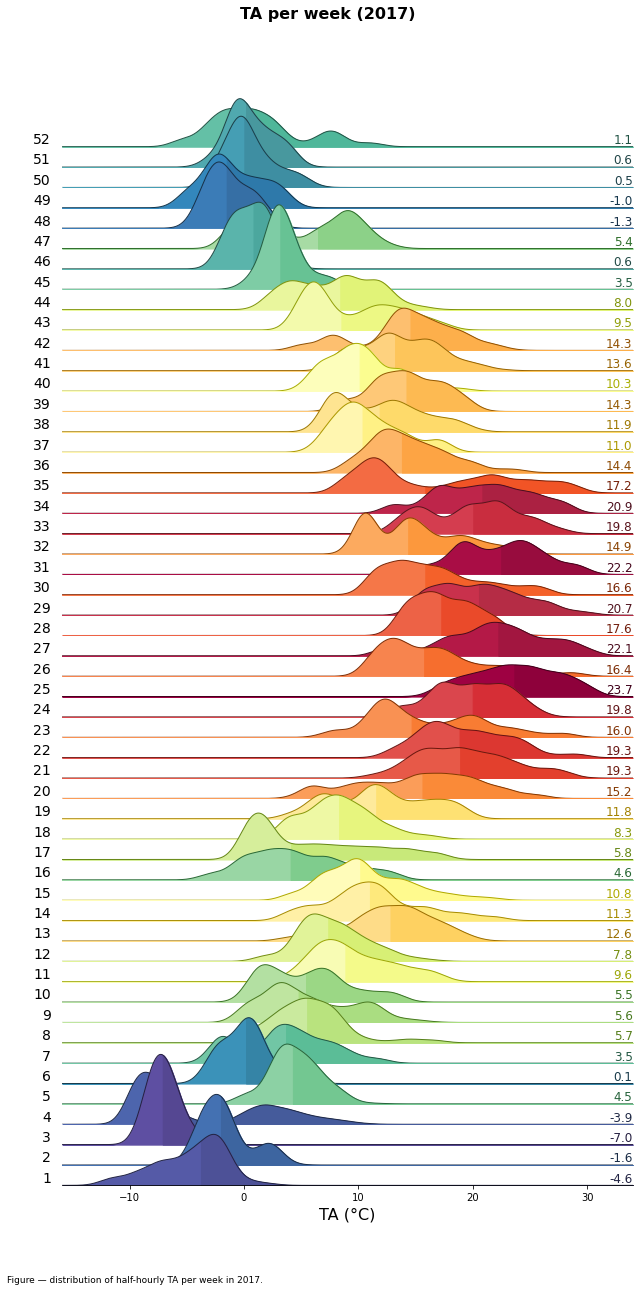

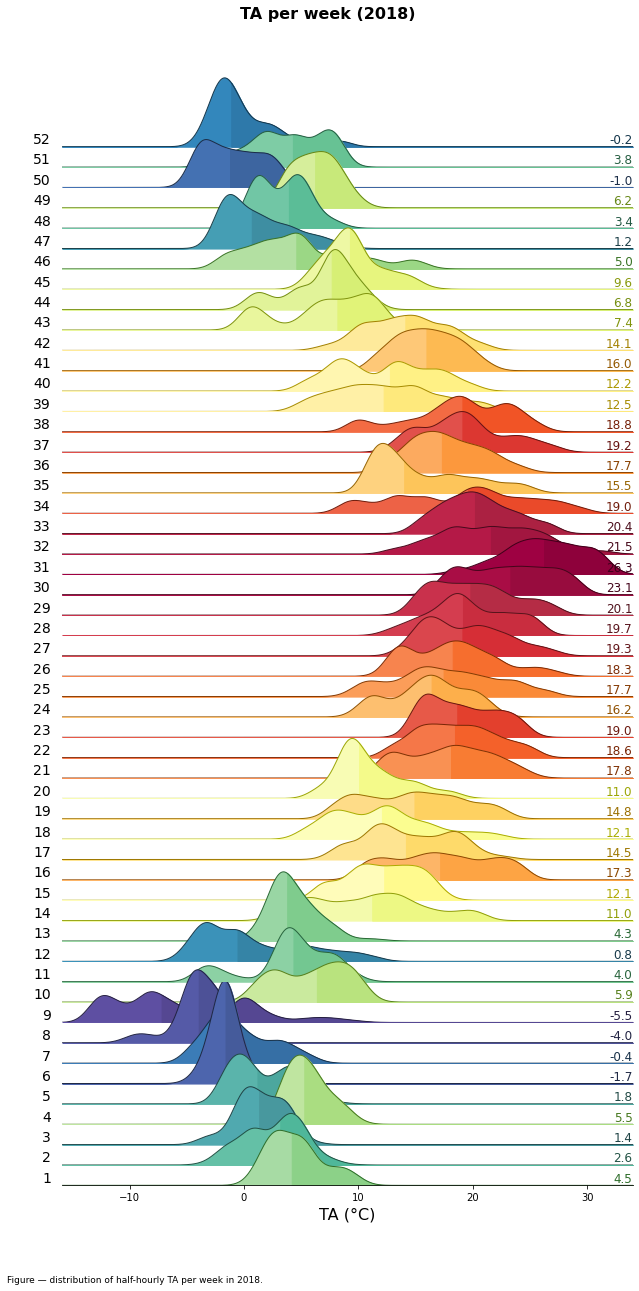

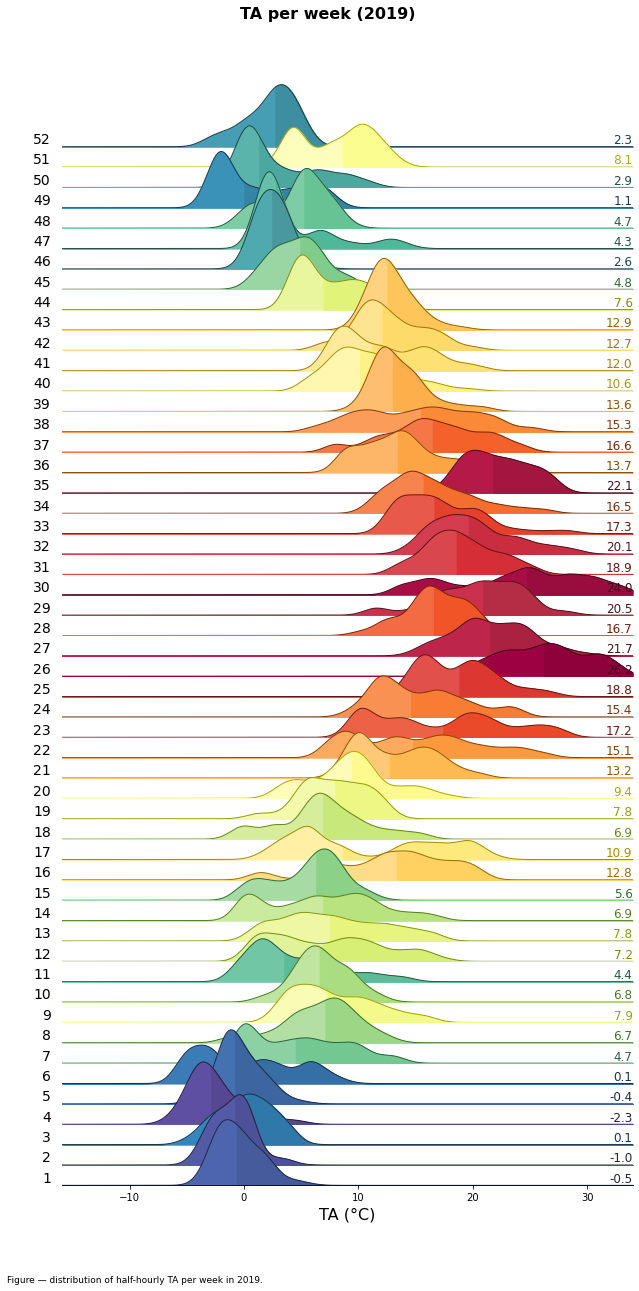

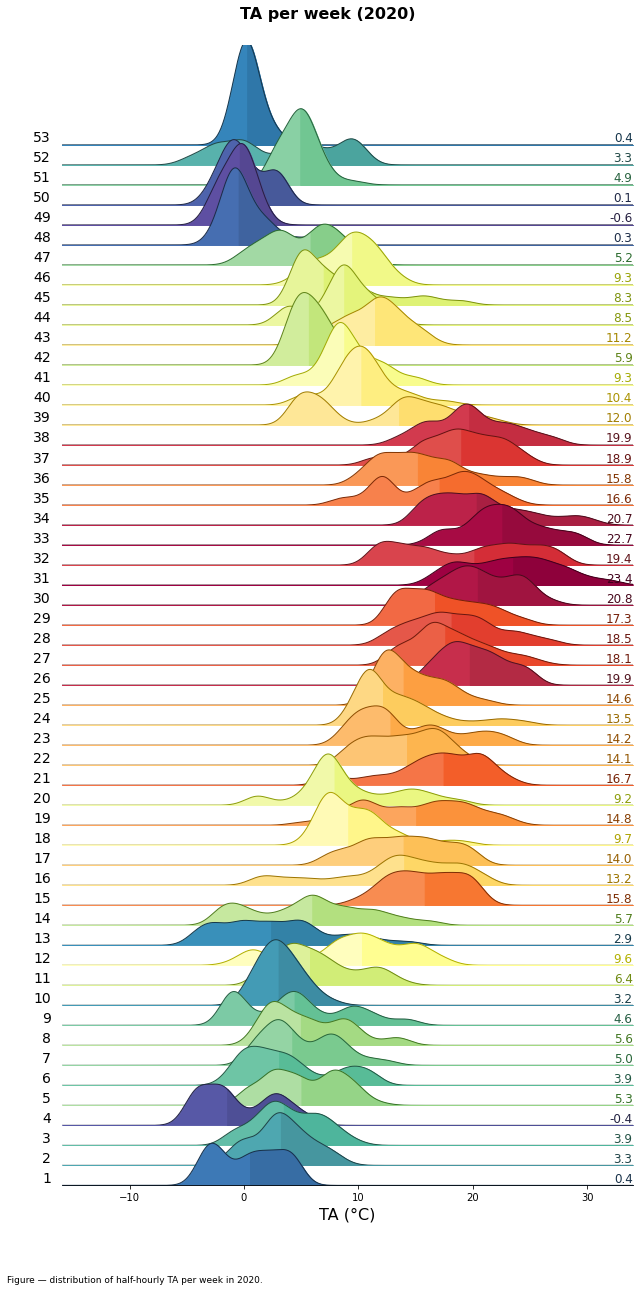

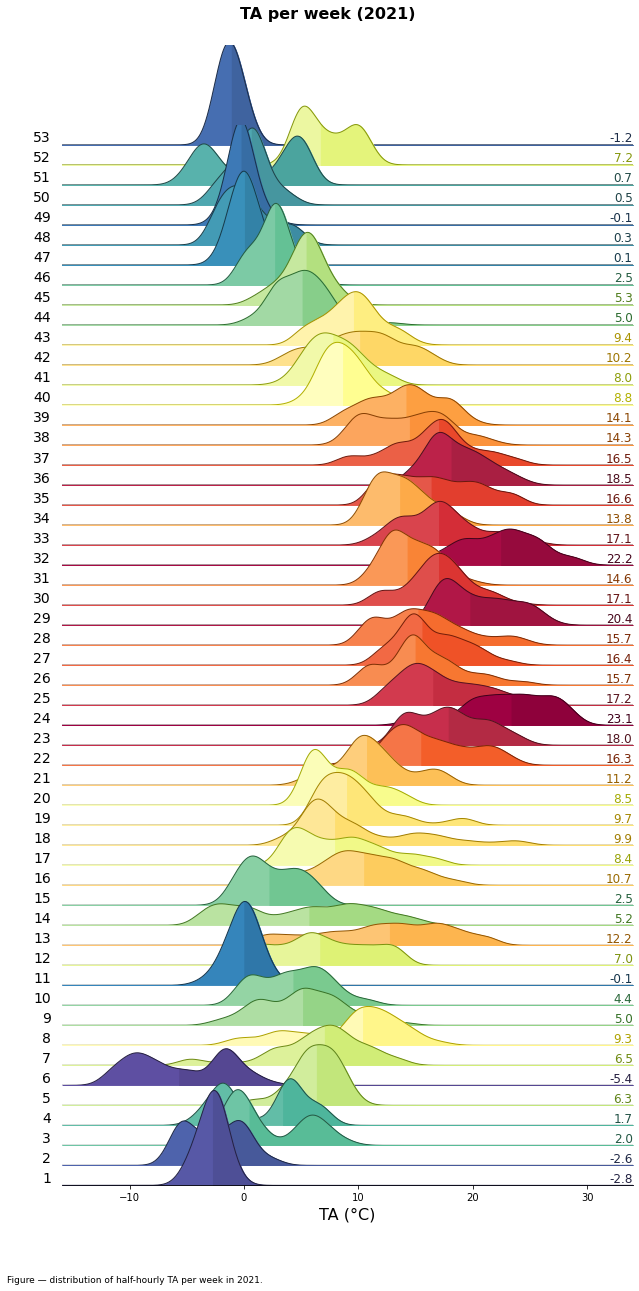

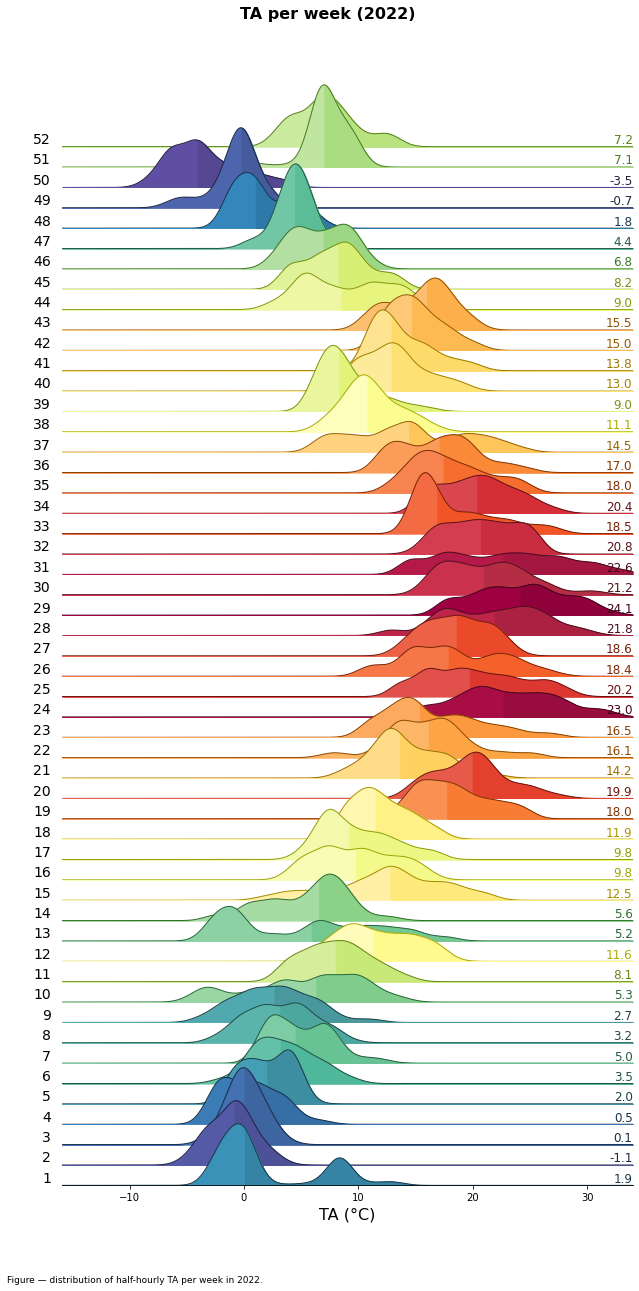

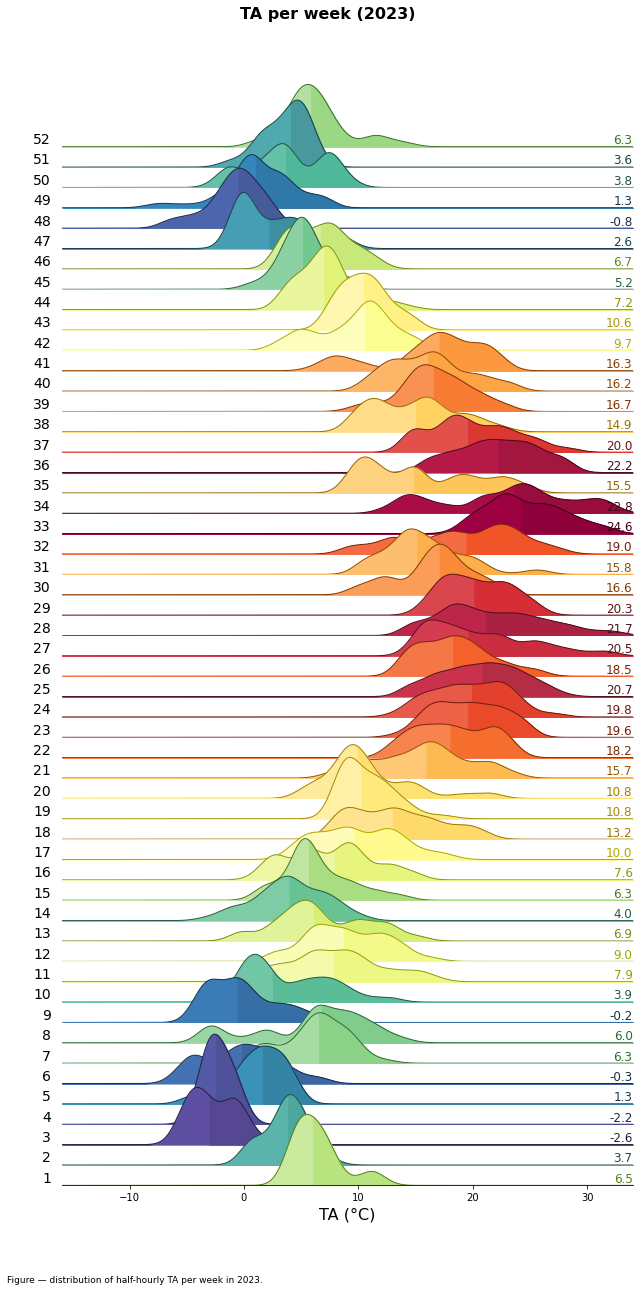

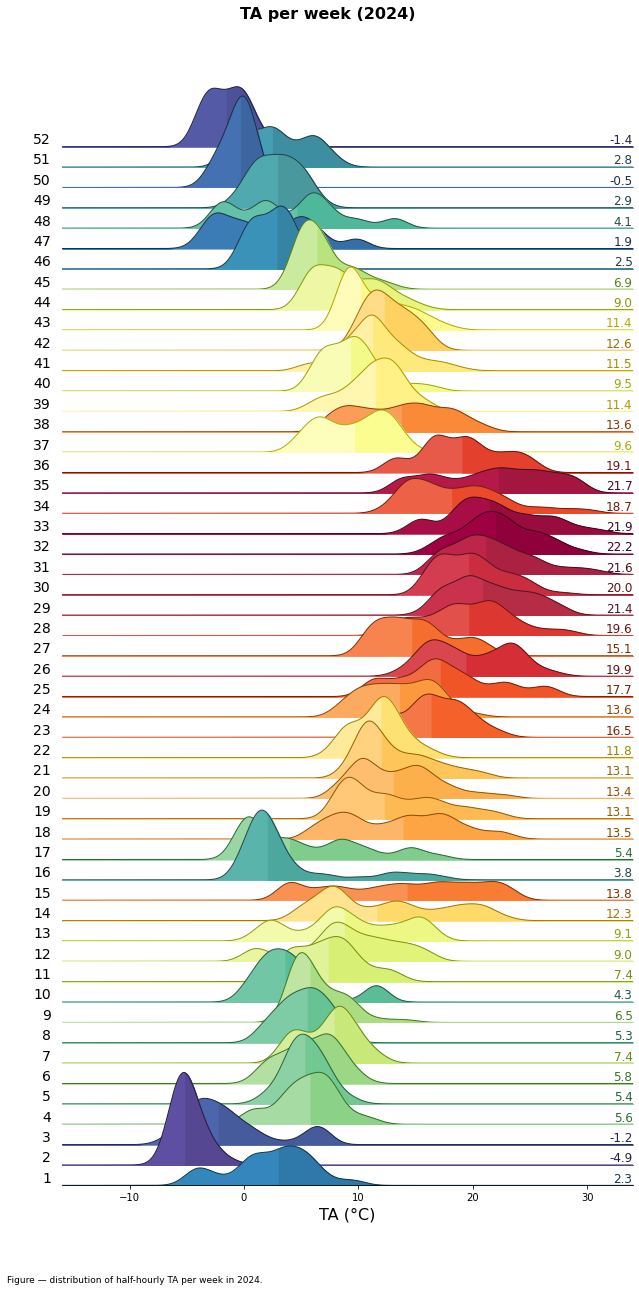

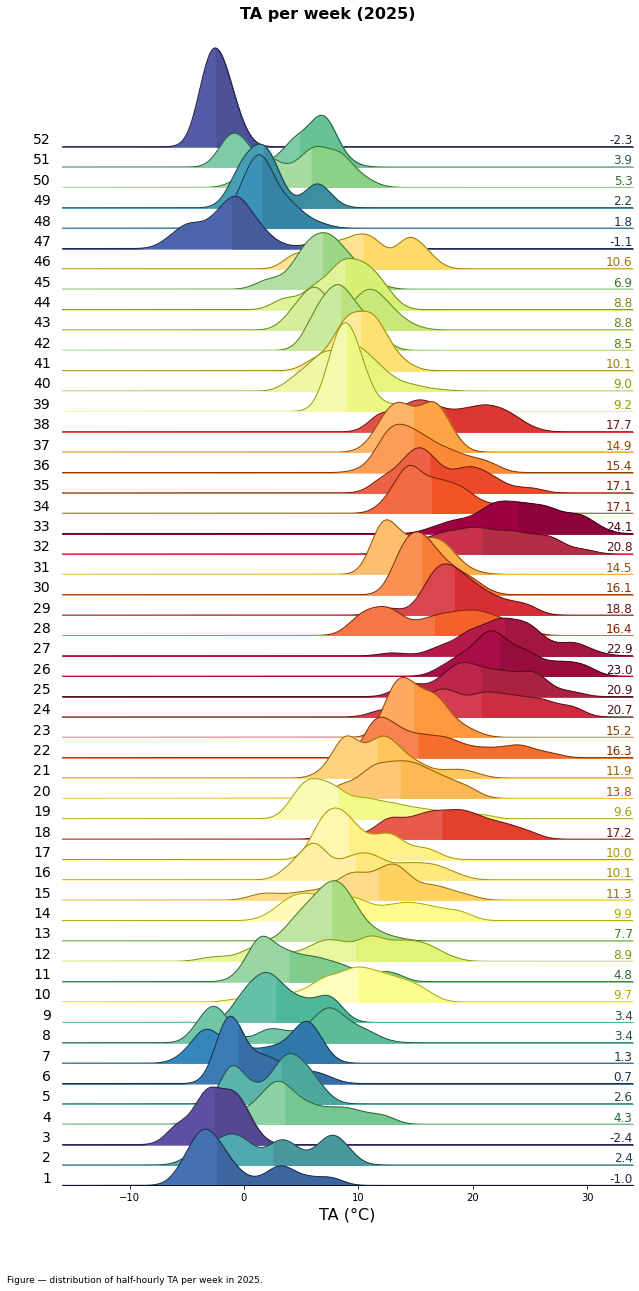

In [49]:
if SHOW_PER_YEAR_DETAIL:
    uniq_years = series.index.year.unique()
    for uy in uniq_years:
        series_yr = series.loc[series.index.year == uy].copy()
        rp = dv.plotting.RidgeLinePlot(series=series_yr)
        rp.plot(
            how='weekly',
            kd_kwargs=None,  # params from scikit KernelDensity as dict
            xlim=xlim,  # min/max as list
            ylim=[0, 0.3],  # min/max as list
            hspace=-0.8,  # overlap
            fig_width=9,
            fig_height=18,
            shade_percentile=0.5,
            show_mean_line=False,
            format_style=dv.plotting.FormatStyle(xlabel=xlabel, title=f"{var} per week ({uy})"),
            fig_dpi=72,
            showplot=True,
            ascending=False
        )
        figcap(rp.fig, f"distribution of half-hourly {var} per week in {uy}.")

</br>

# End of notebook

In [50]:
dt_string = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"Finished. {dt_string}")

Finished. 2026-07-28 02:54:25
